# Poziom 3 - Redukcja i dyskretyzacja danych

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
    df_combined = pd.read_csv('output/combined_part_7.csv')

df_combined['date'] = pd.to_datetime(df_combined['date'])
df_countries = df_combined.query("aggregation_level == 0")

## Część 1

*Analiza zmian zjawisk w czasie porządkuje informacje i pozwala na wyciągnięcie bardziej szczegółowych wniosków, np. trendów ze składowymi okresowymi.*

***Trend** to tendencja rozwojowa, która wskazuje ogólny kierunek rozwoju zjawiska. Rozwój zjawiska rozumiany jest jako systematyczne zmiany, jakim podlega to zjawisko. Rozróżniany jest m.in. trend liniowy i nieliniowy.*

***Składowe okresowe** to regularne odchylenia od trendu. **Wahania cykliczne** charakteryzują się długookresowymi, rytmicznymi odchyleniami. **Wahania sezonowe** są krótkookresowe i odzwierciedlają wpływ zachowań wynikający z kalendarza.*

Wyznacz średnią kroczącą i odchylenie standardowe kroczące (np. 7-dniowe), aby zobaczyć, jak te zjawiska zmieniają się w czasie. Obliczenia wykonaj dla:

#### **1.1.** liczby nowych zachorowań,

In [3]:
df_rolling = df_countries.copy()

rolling_window_size = 14

In [4]:
def rolling_mean_std(df, column, window_size):
    rolling_mean = df[column].rolling(window_size).mean()
    rolling_std = df[column].rolling(window_size).std()

    return rolling_mean, rolling_std


def rolling_mean_std_by_group(df, column, group_column, window_size):
    rolling_mean = df.groupby(group_column)[column].rolling(window_size).mean()
    rolling_mean.reset_index(level=0, drop=True, inplace=True)

    rolling_std = df.groupby(group_column)[column].rolling(window_size).std()
    rolling_std.reset_index(level=0, drop=True, inplace=True)

    return rolling_mean, rolling_std

In [5]:
new_confirmed_rolling_means_by_country, new_confirmed_rolling_stds_by_country = rolling_mean_std_by_group(
    df_rolling, 'new_confirmed', 'country_name', rolling_window_size
)

df_rolling['new_confirmed_rolling_mean'] = new_confirmed_rolling_means_by_country
df_rolling['new_confirmed_rolling_std'] = new_confirmed_rolling_stds_by_country

#### **1.2.** liczby nowych śmierci,

In [6]:
new_deceased_rolling_means_by_country, new_deceased_rolling_stds_by_country = rolling_mean_std_by_group(
    df_rolling, 'new_deceased', 'country_name', rolling_window_size
)

df_rolling['new_deceased_rolling_mean'] = new_deceased_rolling_means_by_country
df_rolling['new_deceased_rolling_std'] = new_deceased_rolling_stds_by_country

#### **1.3.** liczby nowych szczepień,

In [7]:
new_persons_vaccinated_rolling_means_by_country, new_persons_vaccinated_rolling_stds_by_country = rolling_mean_std_by_group(
    df_rolling, 'new_persons_vaccinated', 'country_name', rolling_window_size
)

df_rolling['new_persons_vaccinated_rolling_mean'] = new_persons_vaccinated_rolling_means_by_country
df_rolling['new_persons_vaccinated_rolling_std'] = new_persons_vaccinated_rolling_stds_by_country

#### **1.4.** 2 innych różnych informacji, które uznasz za istotne.

##### **1.4.1.** Trendy wyszukiwań frazy 'depression' w USA.

In [8]:
df_us = df_countries.query("iso_3166_1_alpha_2 == 'US'")

df_us_rolling = df_us.copy()

In [9]:
search_trends_depression_rolling_means, search_trends_depression_rolling_stds = rolling_mean_std(
    df_us_rolling, 'search_trends_depression', rolling_window_size
)

df_us_rolling['search_trends_depression_rolling_mean'] = search_trends_depression_rolling_means
df_us_rolling['search_trends_depression_rolling_std'] = search_trends_depression_rolling_stds

##### **1.4.2.** Indeks jakości powietrza (AQI) dla poszczególnych hrabstw w USA.

In [10]:
df_us_counties = df_combined.query("iso_3166_1_alpha_2 == 'US' & aggregation_level == 2")

df_us_counties_rolling = df_us_counties.copy()

In [11]:
aqi_daily_rolling_means, aqi_daily_rolling_stds = rolling_mean_std(
    df_us_counties_rolling, 'aqi_daily', rolling_window_size
)

df_us_counties_rolling['aqi_daily_rolling_mean'] = aqi_daily_rolling_means
df_us_counties_rolling['aqi_daily_rolling_std'] = aqi_daily_rolling_stds

Możesz przefiltrować dane, jeżeli uznasz to za potrzebne. Sprawdź, czy dla tych informacji można zaobserwować trendy (np. sezonowe wzorce lub cykle) i wahania.

#### Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi itp.). Przeanalizuj otrzymane wizualizacje.

##### **Ad. 1.1.**

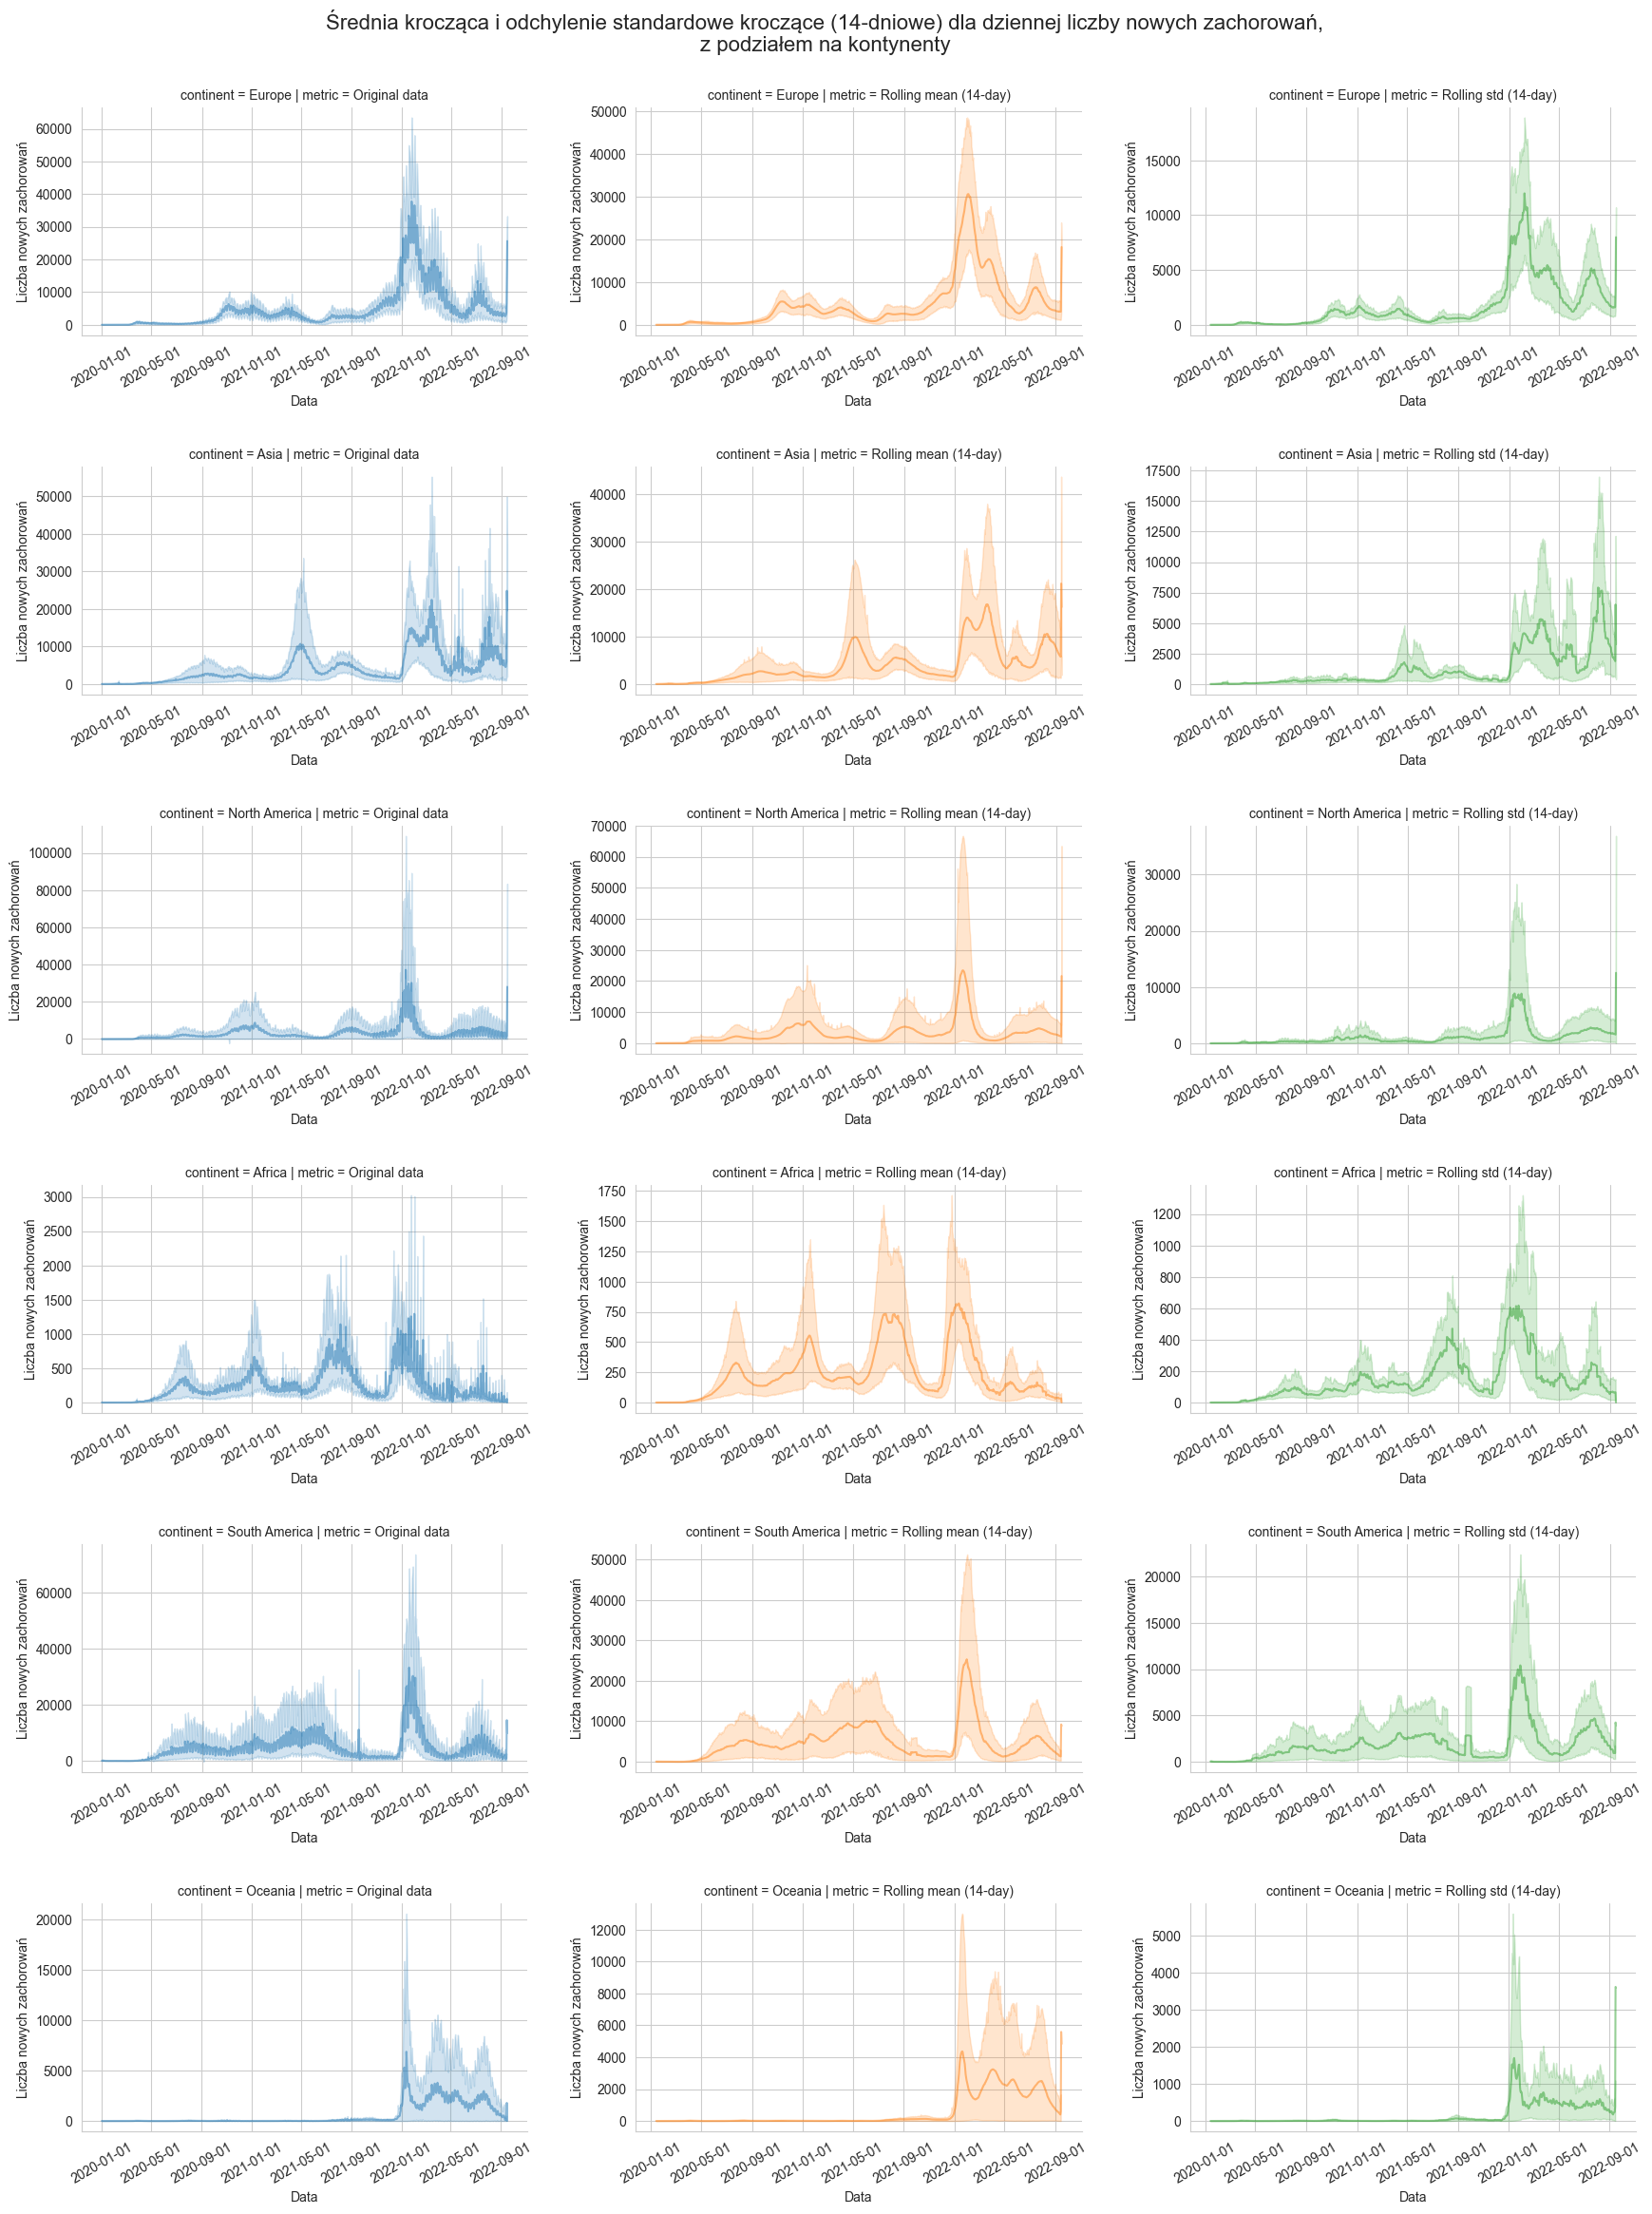

In [12]:
df_plot = df_rolling.melt(
    id_vars=['country_name', 'continent', 'date'],
    value_vars=['new_confirmed', 'new_confirmed_rolling_mean', 'new_confirmed_rolling_std'],
    var_name='metric',
    value_name='value'
)

df_plot['metric'] = df_plot['metric'].replace({
    'new_confirmed': 'Original data',
    'new_confirmed_rolling_mean': f'Rolling mean ({rolling_window_size}-day)',
    'new_confirmed_rolling_std': f'Rolling std ({rolling_window_size}-day)'
})

g = sns.FacetGrid(df_plot, row='continent', col='metric', hue='metric', height=4, aspect=1.5, sharex=False, sharey=False)
g.map(sns.lineplot, 'date', 'value', alpha=0.5)

for ax in g.axes.flatten():
    ax.set_xlabel('Data')
    ax.set_ylabel('Liczba nowych zachorowań')

g.set_xticklabels(rotation=30)

g.fig.suptitle(
    f'Średnia krocząca i odchylenie standardowe kroczące ({rolling_window_size}-dniowe) dla dziennej liczby nowych zachorowań,'
    '\nz podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

##### **Ad. 1.2.**

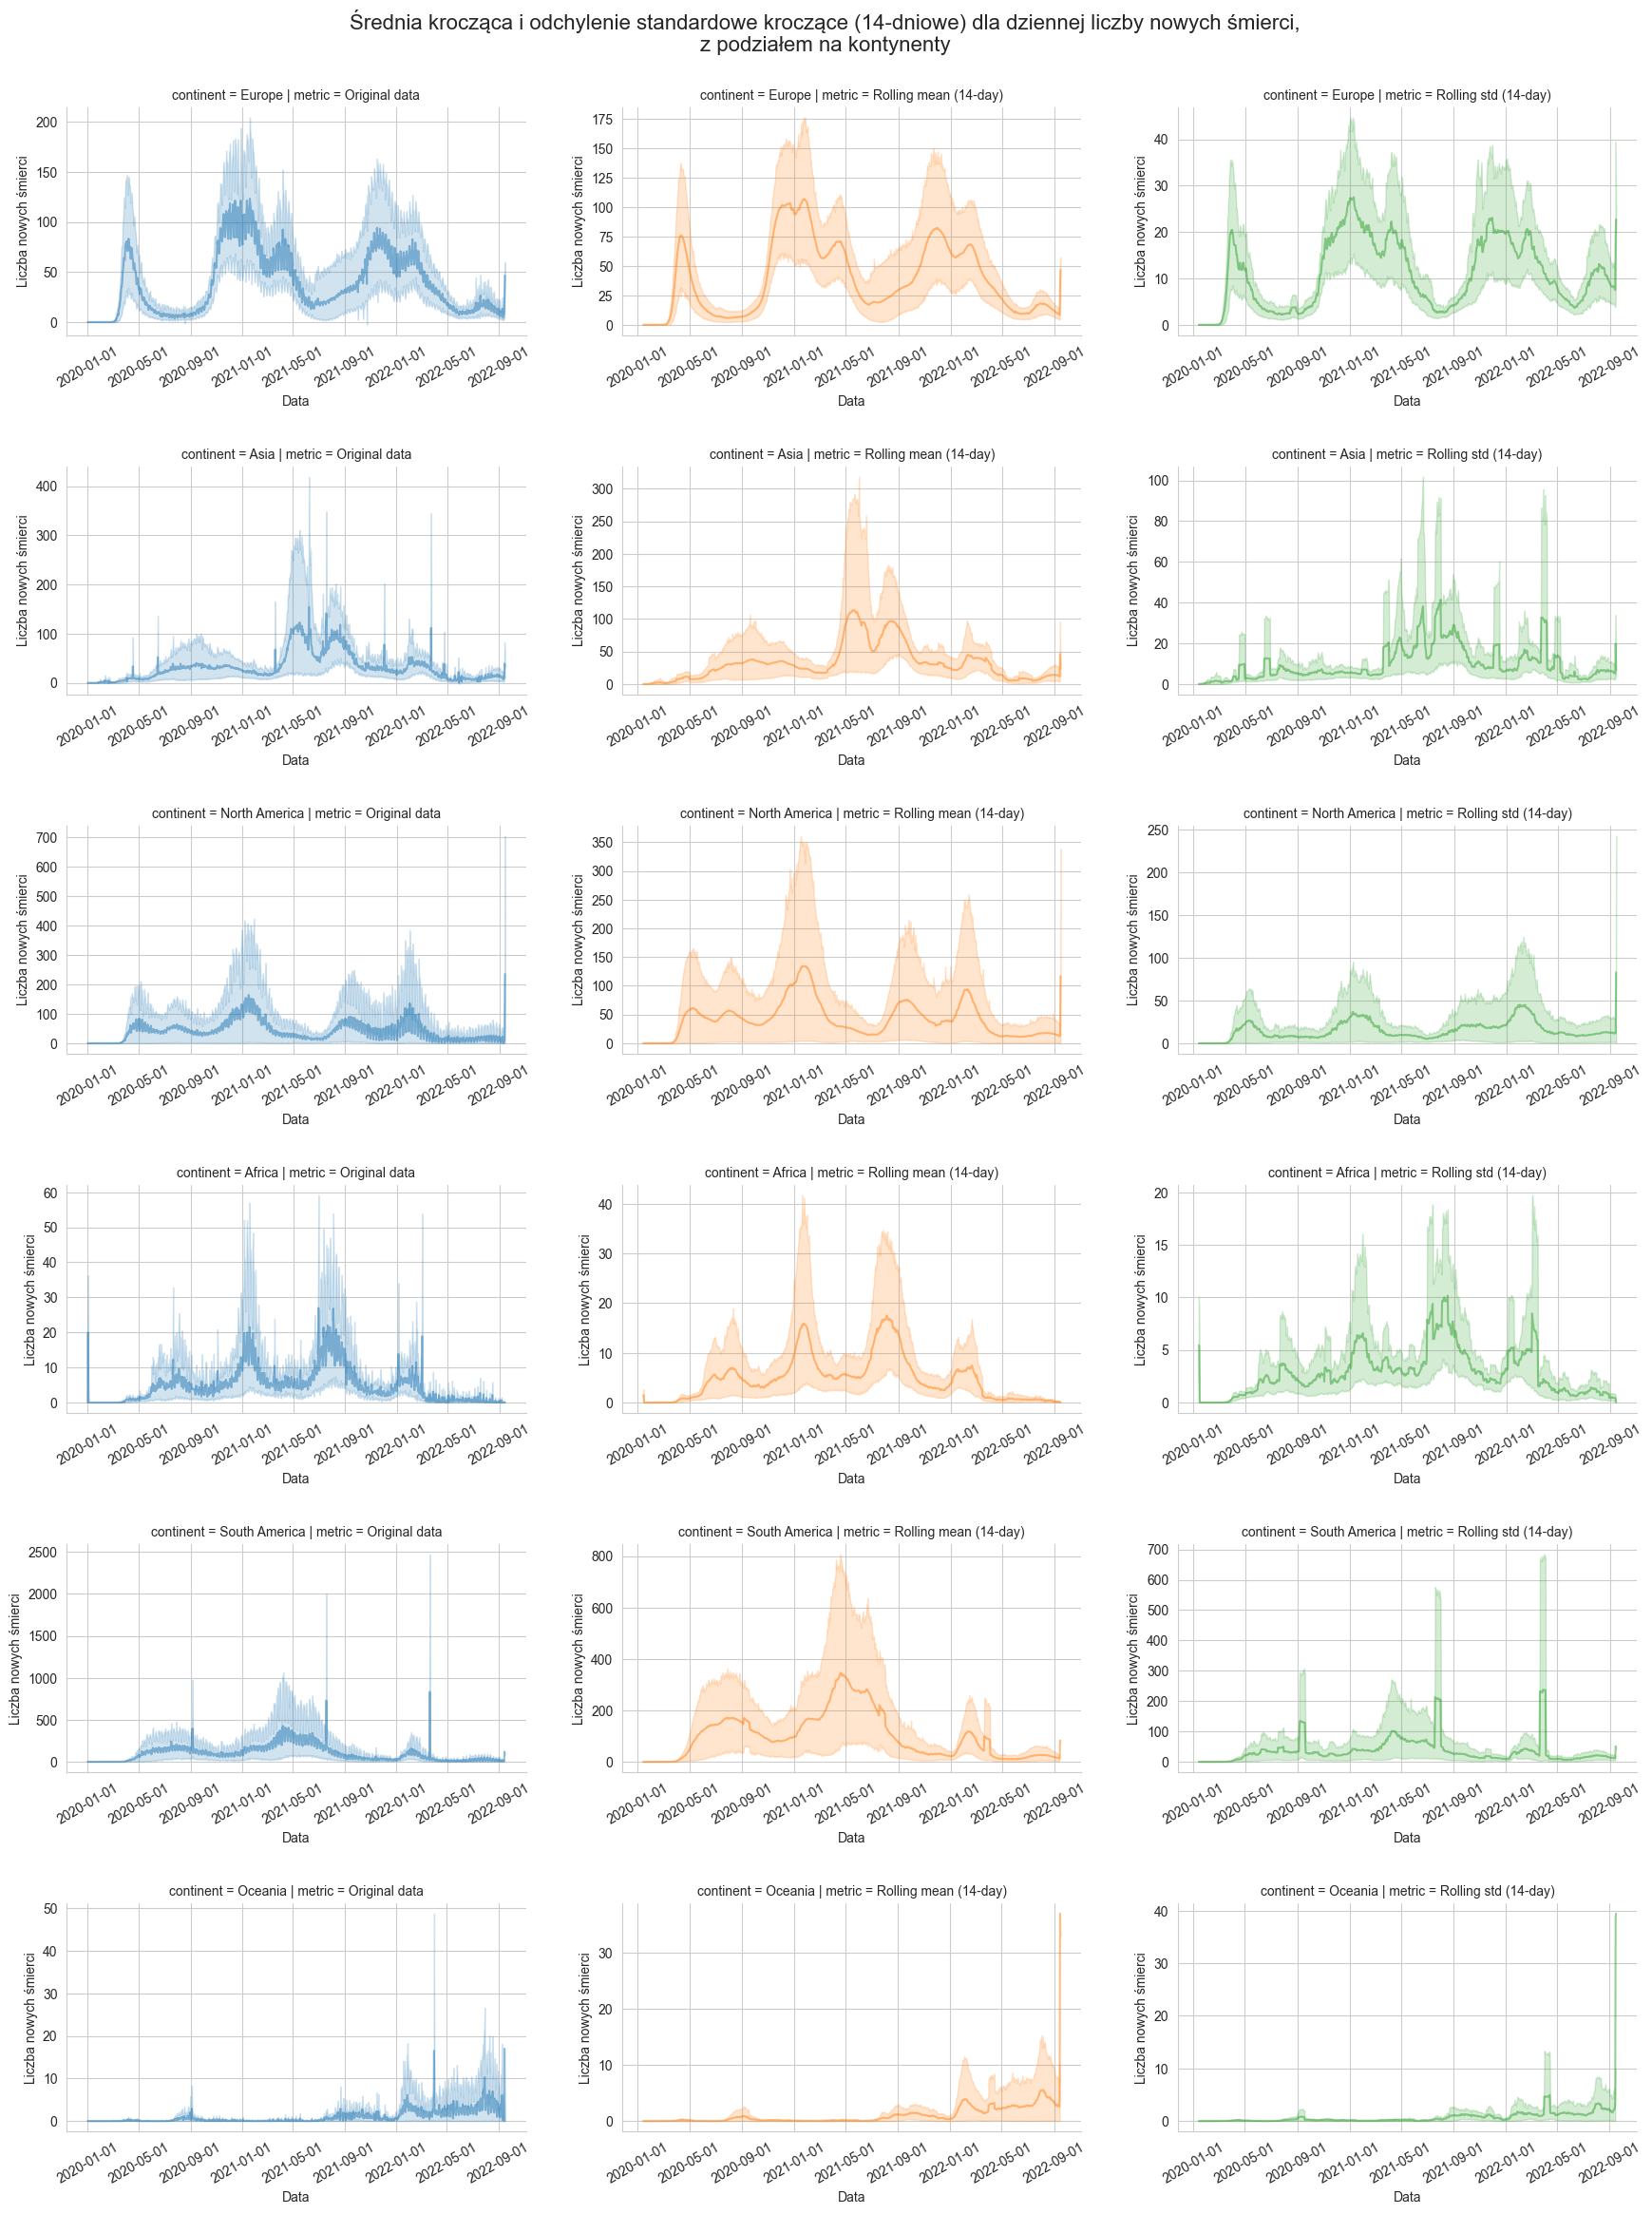

In [13]:
df_plot = df_rolling.melt(
    id_vars=['country_name', 'continent', 'date'],
    value_vars=['new_deceased', 'new_deceased_rolling_mean', 'new_deceased_rolling_std'],
    var_name='metric',
    value_name='value'
)

df_plot['metric'] = df_plot['metric'].replace({
    'new_deceased': 'Original data',
    'new_deceased_rolling_mean': f'Rolling mean ({rolling_window_size}-day)',
    'new_deceased_rolling_std': f'Rolling std ({rolling_window_size}-day)'
})

g = sns.FacetGrid(df_plot, row='continent', col='metric', hue='metric', height=4, aspect=1.5, sharex=False, sharey=False)
g.map(sns.lineplot, 'date', 'value', alpha=0.5)

for ax in g.axes.flatten():
    ax.set_xlabel('Data')
    ax.set_ylabel('Liczba nowych śmierci')

g.set_xticklabels(rotation=30)

g.fig.suptitle(
    f'Średnia krocząca i odchylenie standardowe kroczące ({rolling_window_size}-dniowe) dla dziennej liczby nowych śmierci,'
    '\nz podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

##### **Ad. 1.3.**

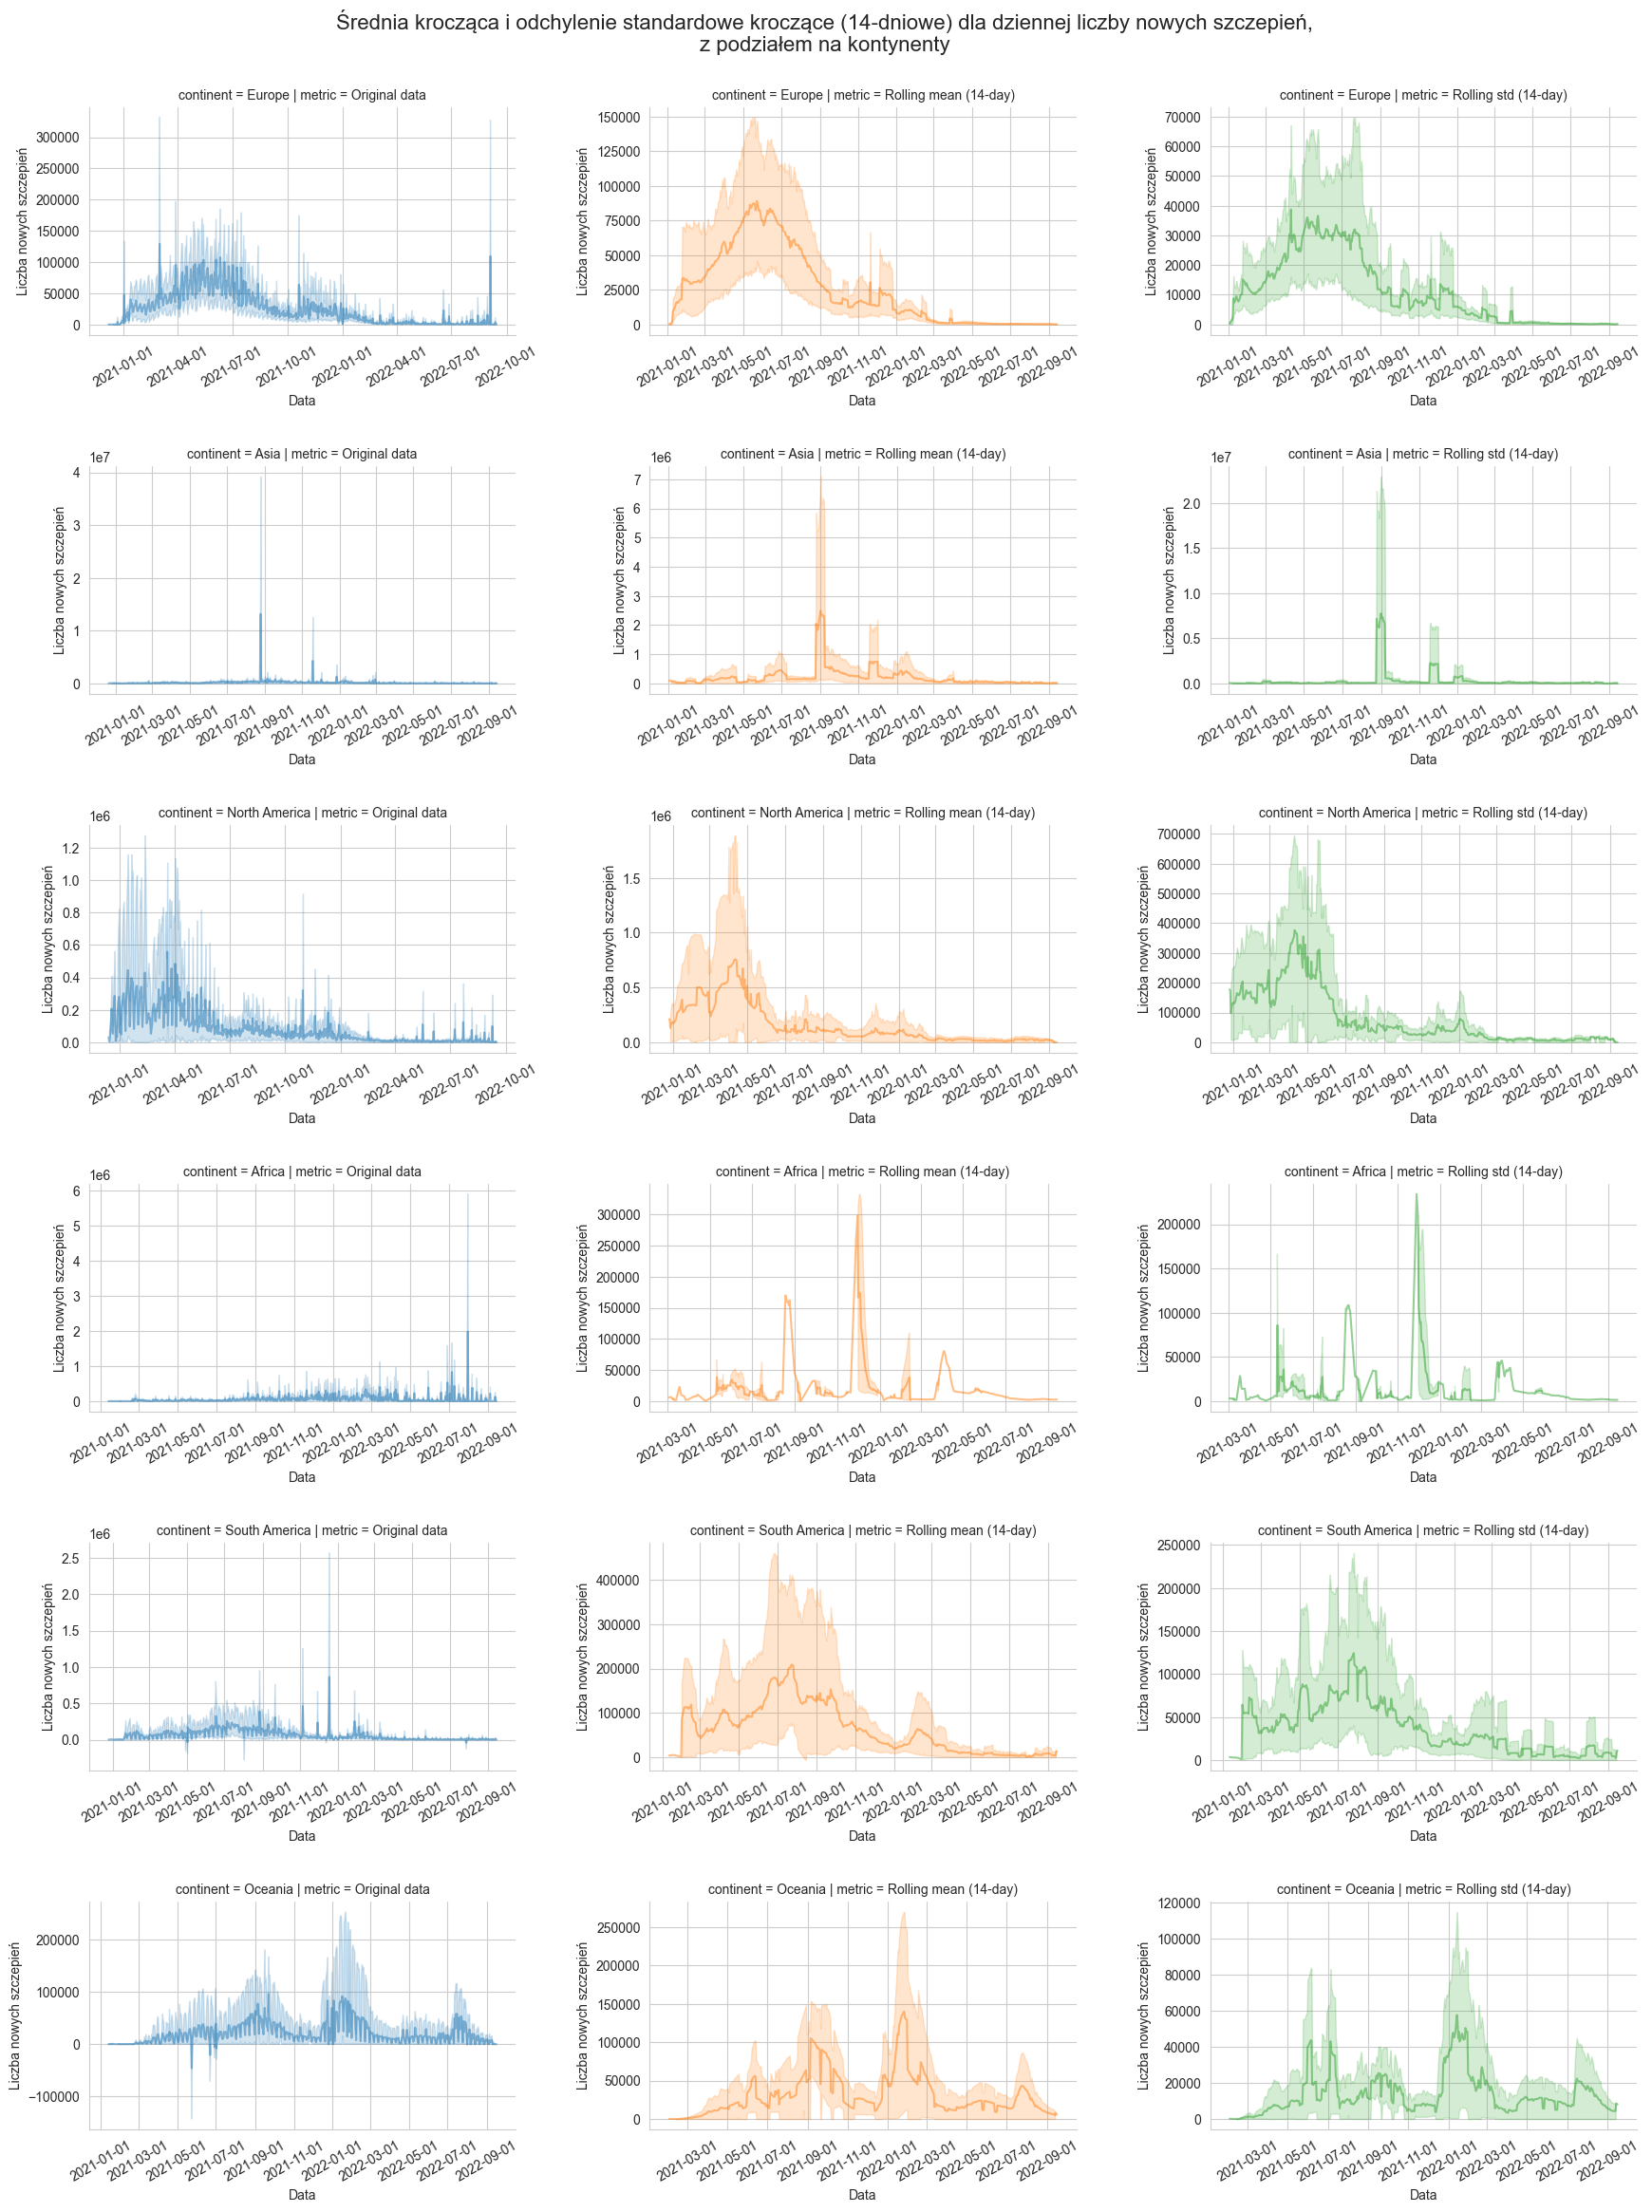

In [14]:
df_plot = df_rolling.melt(
    id_vars=['country_name', 'continent', 'date'],
    value_vars=['new_persons_vaccinated', 'new_persons_vaccinated_rolling_mean', 'new_persons_vaccinated_rolling_std'],
    var_name='metric',
    value_name='value'
)

df_plot['metric'] = df_plot['metric'].replace({
    'new_persons_vaccinated': 'Original data',
    'new_persons_vaccinated_rolling_mean': f'Rolling mean ({rolling_window_size}-day)',
    'new_persons_vaccinated_rolling_std': f'Rolling std ({rolling_window_size}-day)'
})

g = sns.FacetGrid(df_plot, row='continent', col='metric', hue='metric', height=4, aspect=1.5, sharex=False, sharey=False)
g.map(sns.lineplot, 'date', 'value', alpha=0.5)

for ax in g.axes.flatten():
    ax.set_xlabel('Data')
    ax.set_ylabel('Liczba nowych szczepień')

g.set_xticklabels(rotation=30)

g.fig.suptitle(
    f'Średnia krocząca i odchylenie standardowe kroczące ({rolling_window_size}-dniowe) dla dziennej liczby nowych szczepień,'
    '\nz podziałem na kontynenty',
    fontsize=16, y=0.98
)

plt.tight_layout(pad=3)
plt.show()

##### **Ad. 1.4.1.**

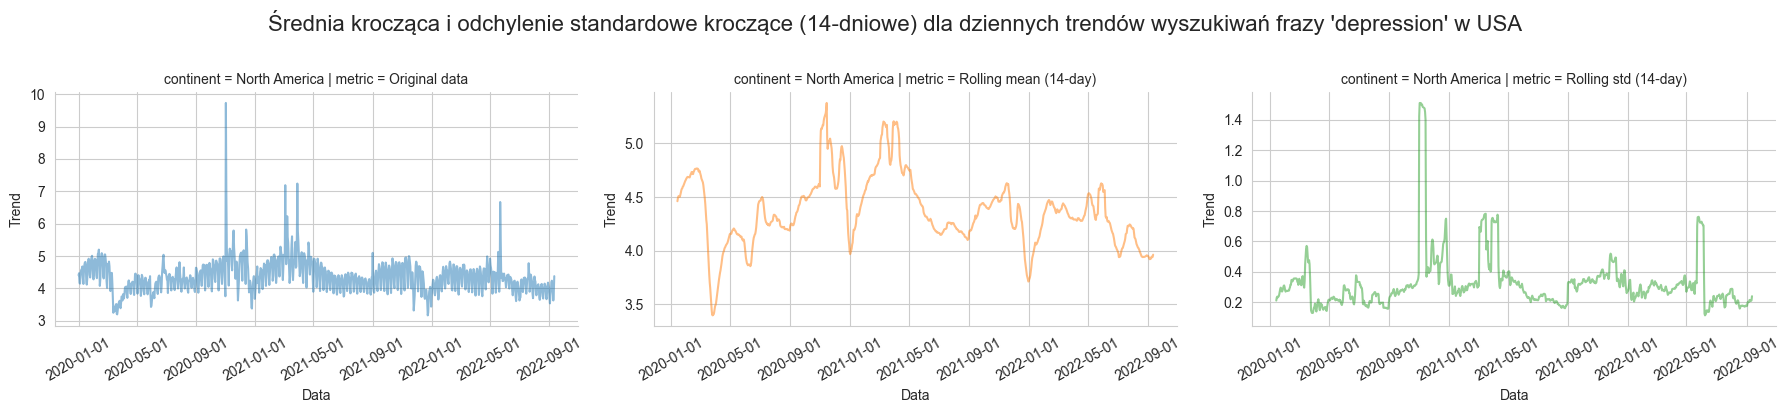

In [15]:
df_plot = df_us_rolling.melt(
    id_vars=['country_name', 'continent', 'date'],
    value_vars=['search_trends_depression', 'search_trends_depression_rolling_mean', 'search_trends_depression_rolling_std'],
    var_name='metric',
    value_name='value'
)

df_plot['metric'] = df_plot['metric'].replace({
    'search_trends_depression': 'Original data',
    'search_trends_depression_rolling_mean': f'Rolling mean ({rolling_window_size}-day)',
    'search_trends_depression_rolling_std': f'Rolling std ({rolling_window_size}-day)'
})

g = sns.FacetGrid(df_plot, row='continent', col='metric', hue='metric', height=4, aspect=1.5, sharex=False, sharey=False)
g.map(sns.lineplot, 'date', 'value', alpha=0.5)

for ax in g.axes.flatten():
    ax.set_xlabel('Data')
    ax.set_ylabel('Trend')

g.set_xticklabels(rotation=30)

g.fig.suptitle(
    f"Średnia krocząca i odchylenie standardowe kroczące ({rolling_window_size}-dniowe) dla dziennych trendów wyszukiwań frazy 'depression' w USA",
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

##### **Ad. 1.4.2.**

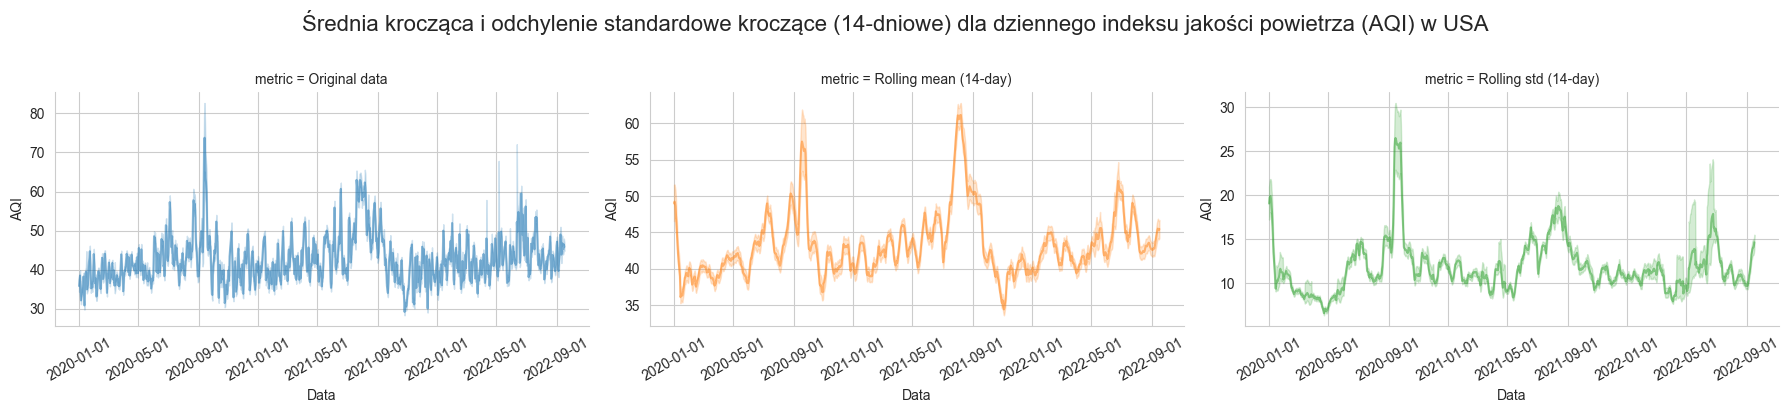

In [16]:
df_plot = df_us_counties_rolling.melt(
    id_vars=['date'],
    value_vars=['aqi_daily', 'aqi_daily_rolling_mean', 'aqi_daily_rolling_std'],
    var_name='metric',
    value_name='value'
)

df_plot['metric'] = df_plot['metric'].replace({
    'aqi_daily': 'Original data',
    'aqi_daily_rolling_mean': f'Rolling mean ({rolling_window_size}-day)',
    'aqi_daily_rolling_std': f'Rolling std ({rolling_window_size}-day)'
})

g = sns.FacetGrid(df_plot, col='metric', hue='metric', height=4, aspect=1.5, sharex=False, sharey=False)
g.map(sns.lineplot, 'date', 'value', alpha=0.5)

for ax in g.axes.flatten():
    ax.set_xlabel('Data')
    ax.set_ylabel('AQI')

g.set_xticklabels(rotation=30)

g.fig.suptitle(
    f'Średnia krocząca i odchylenie standardowe kroczące ({rolling_window_size}-dniowe) dla dziennego indeksu jakości powietrza (AQI) w USA',
    fontsize=16, y=1.02
)

plt.tight_layout()
plt.show()

## Część 2
**Misja dodatkowa – Szeregi czasowe**

***Analiza szeregów czasowych** ma na celu zbadanie zjawiska na podstawie zachodzących zmian w czasie u mierzalnych wartości. Model buduje się na podstawie części systematycznej, tj. trendu oraz wahań cyklicznych i sezonowych. Ewentualne szumy i wahania przypadkowe nie są uwzględniane.*

Wykorzystaj do analizy trendów analizę szeregów czasowych (metoda średniej ruchomej czy inne modele autoregresyjne), która umożliwi zbadanie 5 przypadków rozważanych w części 1 poziomu 3. Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi itp.). Przeanalizuj otrzymane wizualizacje.

In [17]:
import pmdarima as pmd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error

In [18]:
def get_feature_time_series(df, col, date_col='date', freq='D'):
    ts_df = df.copy()
    ts = ts_df.set_index(date_col)[col]

    ts = ts.resample(freq).mean()
    ts = ts.interpolate(method='time').fillna(0)

    return ts


def plot_acf_pacf(ts):
    _, axes = plt.subplots(1, 2, figsize=(10, 5))

    plot_acf(ts, ax=axes[0])
    axes[0].set_xlabel('Lag')

    plot_pacf(ts, ax=axes[1])
    axes[1].set_xlabel('Lag')

    plt.tight_layout()
    plt.show()


def plot_stl(stl_res):
    stl_res.plot()

    plt.xlabel('Data')
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


def plot_arima(ts, preds, feature_name, order, ylim=None):
    mae = mean_absolute_error(ts, preds)

    plt.figure(figsize=(10, 5))
    plt.plot(ts, label='Oryginalne dane')
    plt.plot(preds, alpha=0.8, label='Dopasowany model')

    plt.title(
        f"Model ARIMA dla zmiennej '{feature_name}'."
        f"\nSkładniki: {order}, MAE: {mae:.2f}"
    )

    plt.xlabel('Data')
    plt.ylabel('Wartość zmiennej')

    plt.legend()
    plt.xticks(rotation=30)

    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.show()


def plot_sarima(ts, preds, feature_name, order, seasonal_order):
    mae = mean_absolute_error(ts, preds)

    plt.figure(figsize=(10, 5))
    plt.plot(ts, label='Oryginalne dane')
    plt.plot(preds, alpha=0.8, label='Dopasowany model')

    plt.title(
        f"Model SARIMA dla zmiennej '{feature_name}'."
        f"\nSkładniki niesezonowe: {order}, składniki sezonowe: {seasonal_order}, MAE: {mae:.2f}"
    )

    plt.xlabel('Data')
    plt.ylabel('Wartość zmiennej')

    plt.legend()
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


#### **2.1.** liczba nowych zachorowań,

In [19]:
ts_new_confirmed = get_feature_time_series(df_countries, 'new_confirmed')

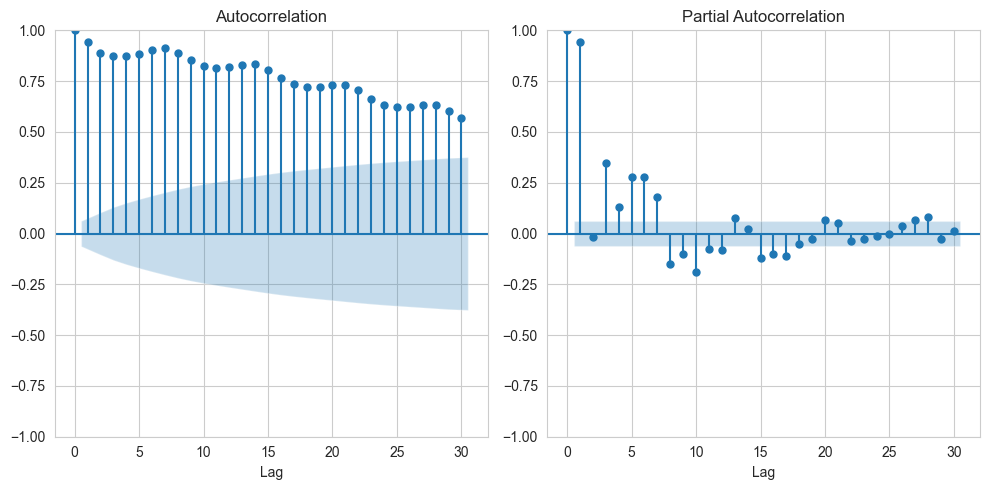

In [20]:
plot_acf_pacf(ts_new_confirmed)

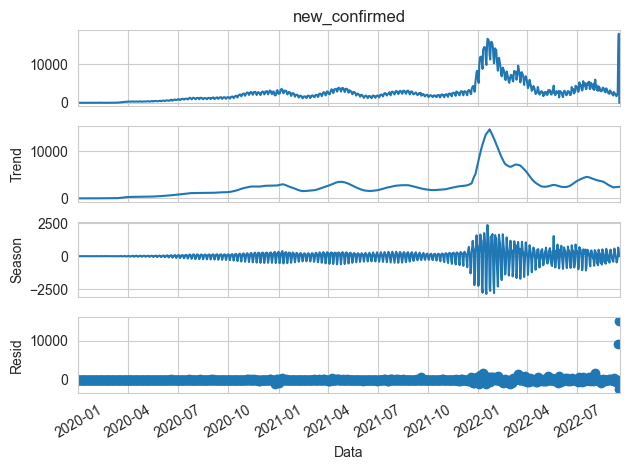

In [21]:
res = STL(ts_new_confirmed, robust=True, period=7).fit()

plot_stl(res)

In [22]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    pmd_arima = pmd.auto_arima(
        ts_new_confirmed, start_p=1, start_q=1, m=7, random_state=42
    )

order = pmd_arima.get_params()['order']
seasonal_order = pmd_arima.get_params()['seasonal_order']

print(f'Order: {order}')
print(f'Seasonal order: {seasonal_order}')

Order: (1, 1, 5)
Seasonal order: (1, 0, 0, 7)


In [23]:
model = SARIMAX(ts_new_confirmed, order=order, seasonal_order=seasonal_order)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    results = model.fit()

predictions = results.predict()

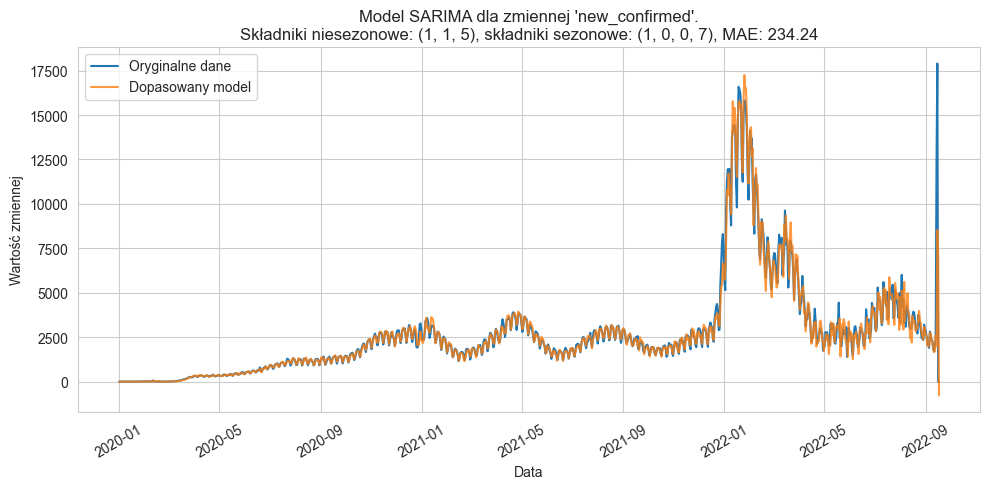

In [24]:
plot_sarima(
    ts_new_confirmed, predictions, 'new_confirmed', order, seasonal_order
)

#### **2.2.** liczba nowych śmierci,

In [25]:
ts_new_deceased = get_feature_time_series(df_countries, 'new_deceased')

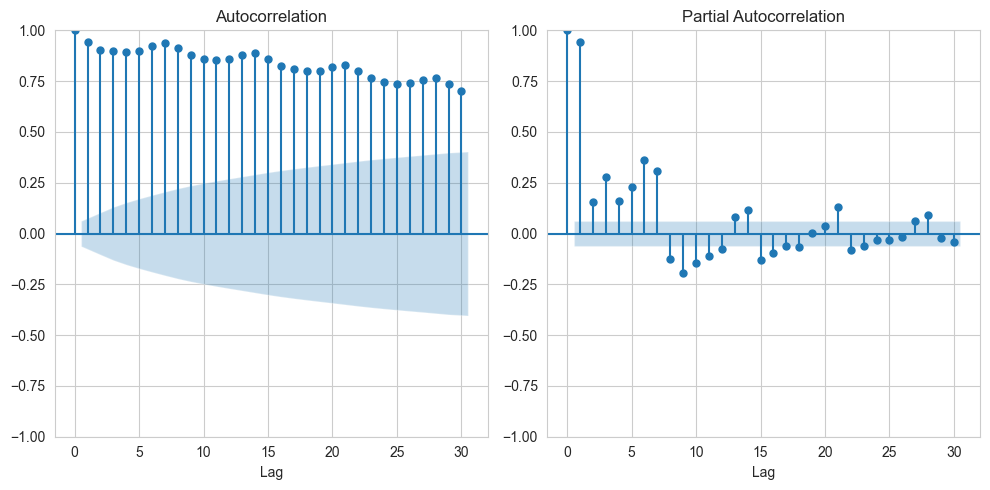

In [26]:
plot_acf_pacf(ts_new_deceased)

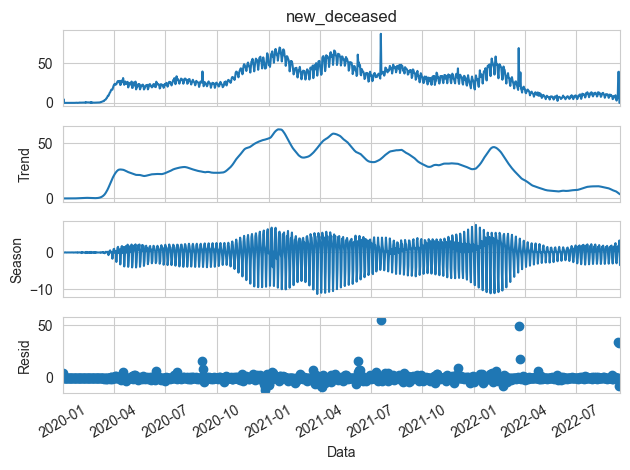

In [27]:
res = STL(ts_new_deceased, robust=True, period=7).fit()

plot_stl(res)

In [28]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    pmd_arima = pmd.auto_arima(
        ts_new_deceased, start_p=1, start_q=1, m=7, random_state=42
    )

order = pmd_arima.get_params()['order']
seasonal_order = pmd_arima.get_params()['seasonal_order']

print(f'Order: {order}')
print(f'Seasonal order: {seasonal_order}')

Order: (2, 1, 1)
Seasonal order: (2, 0, 2, 7)


In [29]:
model = SARIMAX(ts_new_deceased, order=order, seasonal_order=seasonal_order)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    results = model.fit()

predictions = results.predict()

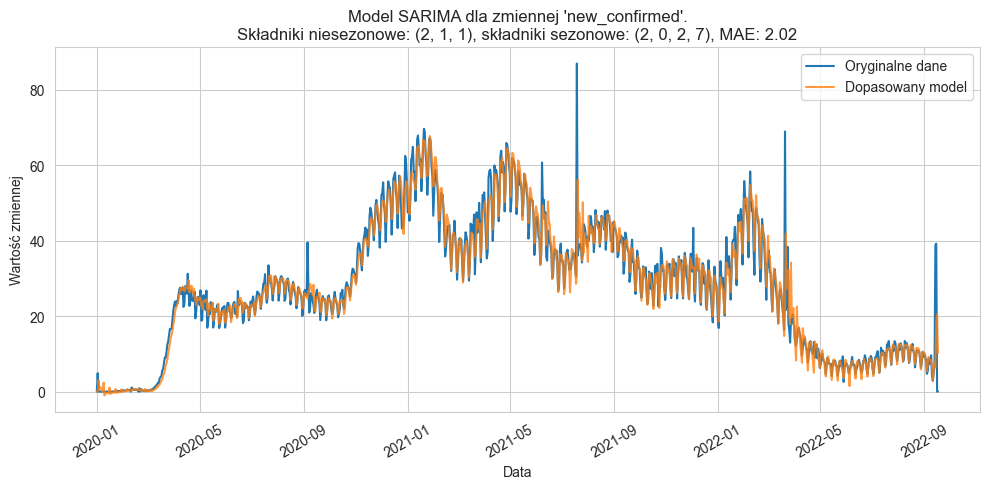

In [30]:
plot_sarima(
    ts_new_deceased, predictions, 'new_confirmed', order, seasonal_order
)

#### **2.3.** liczba nowych szczepień,

In [31]:
ts_new_persons_vaccinated = get_feature_time_series(df_countries, 'new_persons_vaccinated')

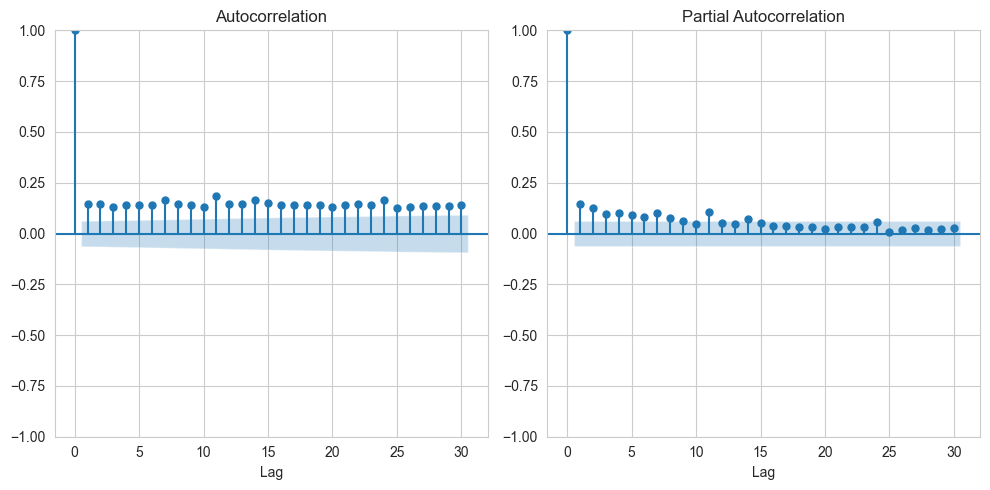

In [32]:
plot_acf_pacf(ts_new_persons_vaccinated)

In [33]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    pmd_arima = pmd.auto_arima(
        ts_new_persons_vaccinated, start_p=1, start_q=1, seasonal=False, random_state=42
    )

order = pmd_arima.get_params()['order']

print(f'Order: {order}')

Order: (0, 1, 3)


In [34]:
model = ARIMA(ts_new_persons_vaccinated, order=order)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    results = model.fit()

predictions = results.predict()

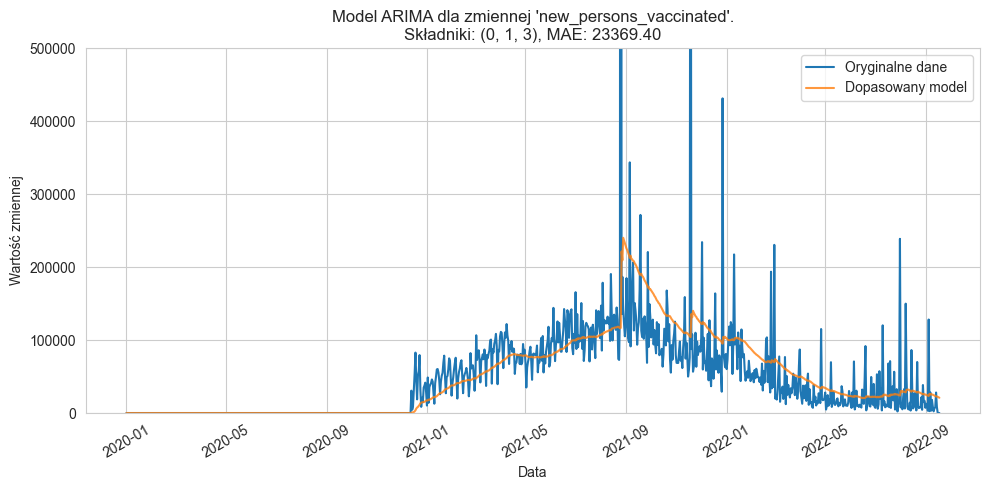

In [35]:
plot_arima(
    ts_new_persons_vaccinated, predictions, 'new_persons_vaccinated', order, (0, 5e5)
)

#### **2.4.** trendy wyszukiwań frazy 'depression',

In [36]:
ts_search_trends_depression = get_feature_time_series(df_countries, 'search_trends_depression')

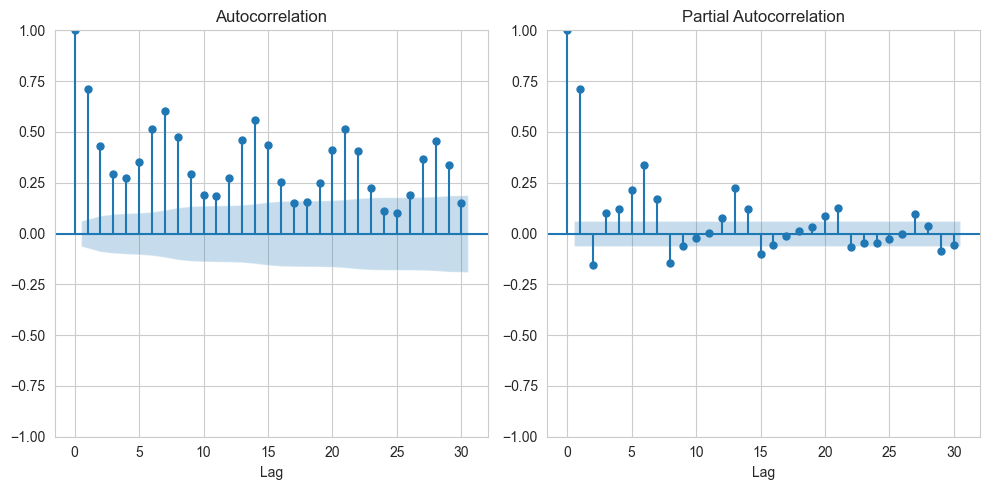

In [37]:
plot_acf_pacf(ts_search_trends_depression)

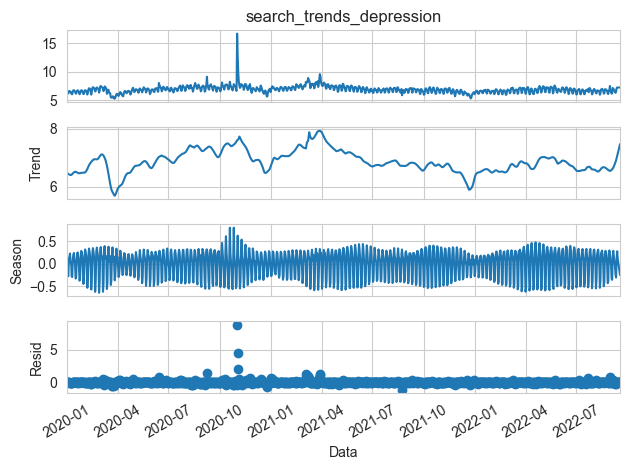

In [38]:
res = STL(ts_search_trends_depression, robust=True, period=7).fit()

plot_stl(res)

In [39]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    pmd_arima = pmd.auto_arima(
        ts_search_trends_depression, start_p=1, start_q=1, m=7, random_state=42
    )

order = pmd_arima.get_params()['order']
seasonal_order = pmd_arima.get_params()['seasonal_order']

print(f'Order: {order}')
print(f'Seasonal order: {seasonal_order}')

Order: (1, 1, 1)
Seasonal order: (2, 0, 2, 7)


In [40]:
model = SARIMAX(ts_search_trends_depression, order=order, seasonal_order=seasonal_order)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=UserWarning)
    results = model.fit()

predictions = results.predict()

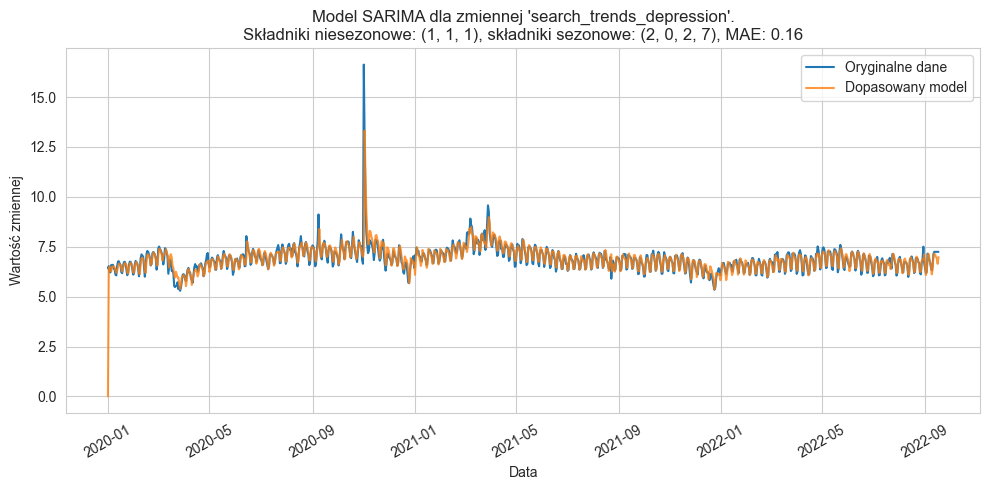

In [41]:
plot_sarima(
    ts_search_trends_depression, predictions, 'search_trends_depression', order, seasonal_order
)

#### **2.5.** indeks jakości powietrza (AQI) dla poszczególnych hrabstw w USA.

In [42]:
ts_aqi_daily = get_feature_time_series(df_us_counties, 'aqi_daily')

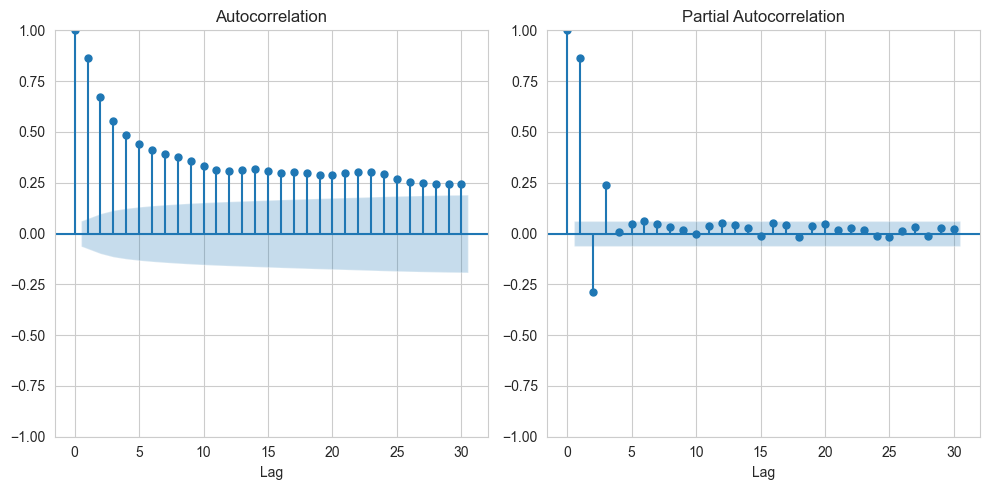

In [43]:
plot_acf_pacf(ts_aqi_daily)

In [44]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning)
    pmd_arima = pmd.auto_arima(
        ts_aqi_daily, start_p=1, start_q=1, seasonal=False, random_state=42
    )

order = pmd_arima.get_params()['order']

print(f'Order: {order}')

Order: (3, 1, 1)


In [45]:
model = ARIMA(ts_aqi_daily, order=order)
results = model.fit()
predictions = results.predict()

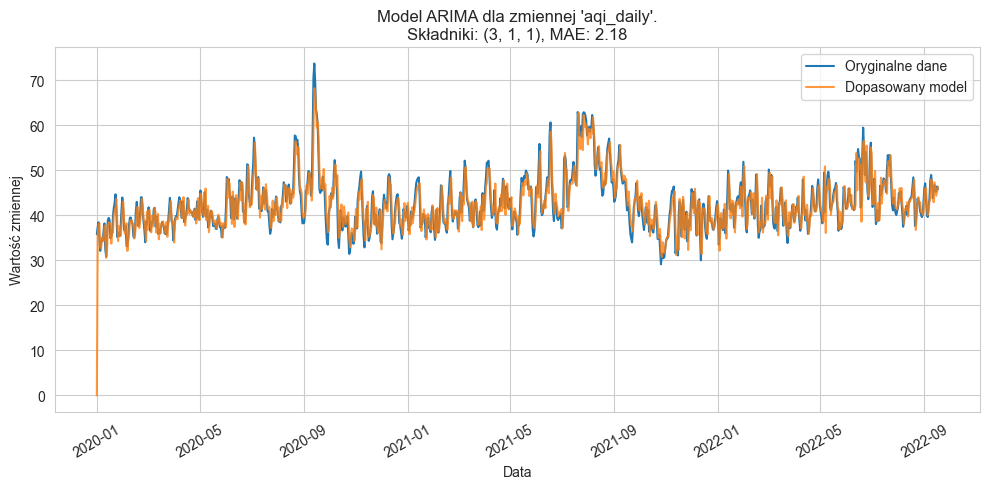

In [46]:
plot_arima(ts_aqi_daily, predictions, 'aqi_daily', order)

## Część 3

***Analiza regresji** pozwala na przewidzenie nieznanych wartości na podstawie innych, które są znane. Jest to metoda statystyczna, która opisuje współzmienności kilku zmiennych przez dopasowanie do nich odpowiedniej funkcji. Model regresji liniowej zakłada liniową zależność między zmienną niezależną (np. czasem) a zmienną zależną (np. liczbą nowych zachorowań).*

Przygotuj dane treningowe w interesującym Cię okresie (np. druga połowa 2020 roku i pierwsza połowa 2021 roku, tj. 52 tygodnie = X) oraz dane testowe. Możesz przefiltrować dane także po innych kryteriach, jeżeli uznasz to za potrzebne. Zastosuj analizę regresji, aby przewidzieć wartości w kolejnych X tygodniach następujących po wybranym okresie treningowym. Użyj modelu regresji liniowej, gdzie zmienną niezależną będzie czas, a zmienną zależną:

#### **3.1.** liczba nowych zachorowań,

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [48]:
df_us_filtered_by_date = df_us.copy()

df_us_filtered_by_date = df_us_filtered_by_date[
    (df_us_filtered_by_date['date'] >= '2020-09-01') &
    (df_us_filtered_by_date['date'] <= '2021-06-01')
]

df_us_filtered_by_date['date_delta'] = (
        (df_us_filtered_by_date['date'] - df_us_filtered_by_date['date'].min()) /
        np.timedelta64(1, 'D')
)

In [49]:
X_new_confirmed = df_us_filtered_by_date[['date_delta']]
y_new_confirmed = df_us_filtered_by_date['new_confirmed']

X_new_confirmed_train, X_new_confirmed_test, y_new_confirmed_train, y_new_confirmed_test = (
    train_test_split(X_new_confirmed, y_new_confirmed, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_new_confirmed_train, y_new_confirmed_train)
y_new_confirmed_fit = reg.predict(X_new_confirmed_train)
y_new_confirmed_pred = reg.predict(X_new_confirmed_test)

mape = mean_absolute_percentage_error(y_new_confirmed_test, y_new_confirmed_pred)
r2 = r2_score(y_new_confirmed_test, y_new_confirmed_pred)

print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Mean absolute percentage error: 783.3941560953409%
R2 score: -61.7524433689686


#### **3.2.** liczba nowych śmierci,

In [50]:
X_new_deceased = df_us_filtered_by_date[['date_delta']]
y_new_deceased = df_us_filtered_by_date['new_deceased']

X_new_deceased_train, X_new_deceased_test, y_new_deceased_train, y_new_deceased_test = (
    train_test_split(X_new_deceased, y_new_deceased, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_new_deceased_train, y_new_deceased_train)
y_new_deceased_fit = reg.predict(X_new_deceased_train)
y_new_deceased_pred = reg.predict(X_new_deceased_test)

mape = mean_absolute_percentage_error(y_new_deceased_test, y_new_deceased_pred)
r2 = r2_score(y_new_deceased_test, y_new_deceased_pred)

print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Mean absolute percentage error: 551.0722090122295%
R2 score: -14.165897162561338


#### **3.3.** liczba nowych szczepień,

In [51]:
X_new_persons_vaccinated = df_us_filtered_by_date[['date_delta']]
y_new_persons_vaccinated = df_us_filtered_by_date['new_persons_vaccinated'].fillna(0)

X_new_persons_vaccinated_train, X_new_persons_vaccinated_test, y_new_persons_vaccinated_train, y_new_persons_vaccinated_test = (
    train_test_split(X_new_persons_vaccinated, y_new_persons_vaccinated, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_new_persons_vaccinated_train, y_new_persons_vaccinated_train)
y_new_persons_vaccinated_fit = reg.predict(X_new_persons_vaccinated_train)
y_new_persons_vaccinated_pred = reg.predict(X_new_persons_vaccinated_test)

mape = mean_absolute_percentage_error(y_new_persons_vaccinated_test, y_new_persons_vaccinated_pred)
r2 = r2_score(y_new_persons_vaccinated_test, y_new_persons_vaccinated_pred)

print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Mean absolute percentage error: 60.27186362734419%
R2 score: -0.7890905319745896


#### **3.4.** 2 inne różne informacje, które uznasz za istotne.

##### **3.4.1.** Trendy wyszukiwań frazy 'depression'.

In [52]:
X_search_trends_depression = df_us_filtered_by_date[['date_delta']]
y_search_trends_depression = df_us_filtered_by_date['search_trends_depression']

X_search_trends_depression_train, X_search_trends_depression_test, y_search_trends_depression_train, y_search_trends_depression_test = (
    train_test_split(X_search_trends_depression, y_search_trends_depression, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_search_trends_depression_train, y_search_trends_depression_train)
y_search_trends_depression_fit = reg.predict(X_search_trends_depression_train)
y_search_trends_depression_pred = reg.predict(X_search_trends_depression_test)

mape = mean_absolute_percentage_error(y_search_trends_depression_test, y_search_trends_depression_pred)
r2 = r2_score(y_search_trends_depression_test, y_search_trends_depression_pred)

print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Mean absolute percentage error: 8.372743338946966%
R2 score: -0.29340205633885064


##### **3.4.2.** Łączna liczba podanych dawek szczepionek.

In [53]:
X_cumulative_vaccine_doses_administered = df_us_filtered_by_date[['date_delta']]
y_cumulative_vaccine_doses_administered = df_us_filtered_by_date['cumulative_vaccine_doses_administered'].fillna(0)

X_cumulative_vaccine_doses_administered_train, X_cumulative_vaccine_doses_administered_test, y_cumulative_vaccine_doses_administered_train, y_cumulative_vaccine_doses_administered_test = (
    train_test_split(X_cumulative_vaccine_doses_administered, y_cumulative_vaccine_doses_administered, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_cumulative_vaccine_doses_administered_train, y_cumulative_vaccine_doses_administered_train)
y_cumulative_vaccine_doses_administered_fit = reg.predict(X_cumulative_vaccine_doses_administered_train)
y_cumulative_vaccine_doses_administered_pred = reg.predict(X_cumulative_vaccine_doses_administered_test)

mape = mean_absolute_percentage_error(y_cumulative_vaccine_doses_administered_test, y_cumulative_vaccine_doses_administered_pred)
r2 = r2_score(y_cumulative_vaccine_doses_administered_test, y_cumulative_vaccine_doses_administered_pred)

print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Mean absolute percentage error: 91.43256983129072%
R2 score: -2.4271053972034347


#### Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi itp.). Przeanalizuj otrzymane wizualizacje.

In [54]:
def plot_linear_regression(y_train, y_test, y_pred_train, y_pred_test, dates_series, var_name, ax=None):
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    train_test_split_idx = len(y_train)
    dates_train = dates_series[:train_test_split_idx]
    dates_test = dates_series[train_test_split_idx:]

    df_train = pd.DataFrame({
        'date': dates_train,
        'y_true': y_train,
        'y_pred': y_pred_train,
        'dataset': 'train'
    })

    df_test = pd.DataFrame({
        'date': dates_test,
        'y_true': y_test,
        'y_pred': y_pred_test,
        'dataset': 'test'
    })

    df_all = pd.concat([df_train, df_test], ignore_index=True)

    if ax is None:
        _, ax = plt.subplots()

    sns.lineplot(data=df_all, x='date', y='y_true', hue='dataset', style='dataset', ax=ax)
    sns.lineplot(data=df_all, x='date', y='y_pred', hue='dataset', legend=False, ax=ax)

    ax.set_xlabel('Data')
    ax.set_ylabel('Wartość zmiennej zależnej')
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)

    ax.set_title(f"Model regresji liniowej dla zmiennej zależnej '{var_name}'"
              f'\n MAPE: {mape * 100:.2f}%, R2: {r2:.2f}',
              fontsize=12, y=1.05)

    plt.tight_layout()


##### **Ad. 3.1.**

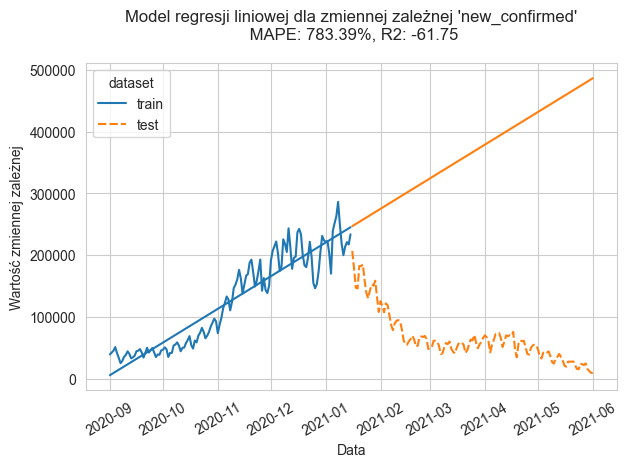

In [55]:
plot_linear_regression(
    y_new_confirmed_train, y_new_confirmed_test,
    y_new_confirmed_fit, y_new_confirmed_pred,
    df_us_filtered_by_date['date'], 'new_confirmed'
)

##### **Ad. 3.2.**

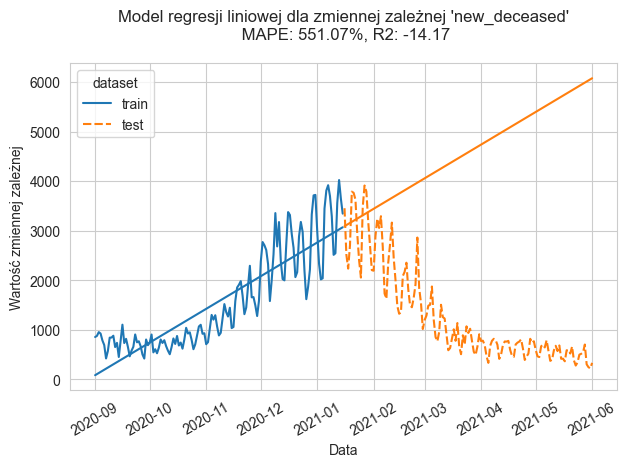

In [56]:
plot_linear_regression(
    y_new_deceased_train, y_new_deceased_test,
    y_new_deceased_fit, y_new_deceased_pred,
    df_us_filtered_by_date['date'], 'new_deceased'
)

##### **Ad. 3.3.**

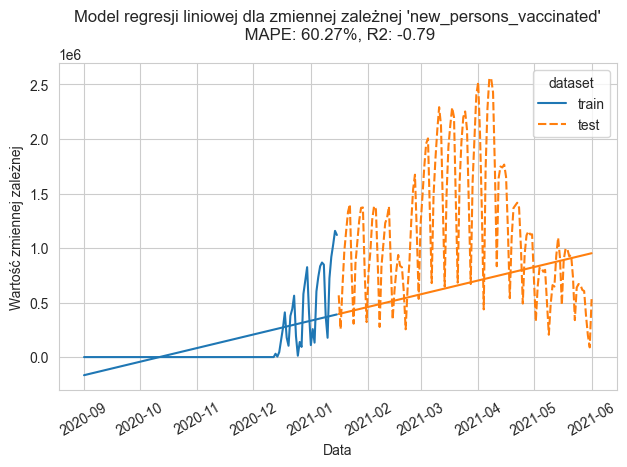

In [57]:
plot_linear_regression(
    y_new_persons_vaccinated_train, y_new_persons_vaccinated_test,
    y_new_persons_vaccinated_fit, y_new_persons_vaccinated_pred,
    df_us_filtered_by_date['date'], 'new_persons_vaccinated'
)

##### **Ad. 3.4.1.**

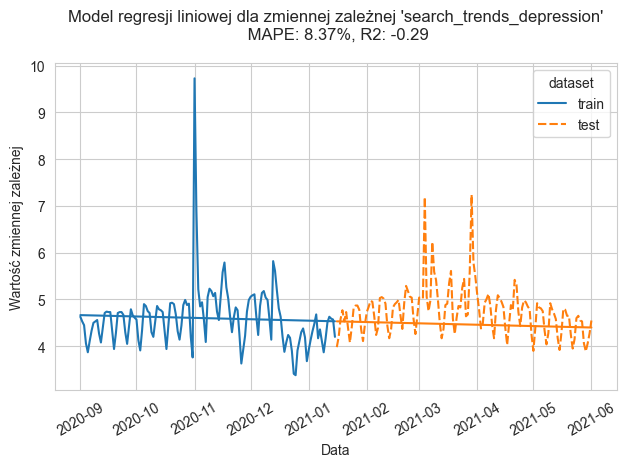

In [58]:
plot_linear_regression(
    y_search_trends_depression_train, y_search_trends_depression_test,
    y_search_trends_depression_fit, y_search_trends_depression_pred,
    df_us_filtered_by_date['date'], 'search_trends_depression'
)

##### **Ad. 3.4.2.**

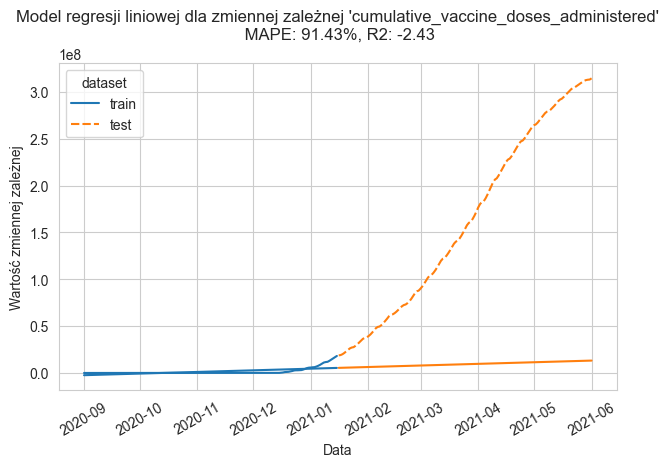

In [59]:
plot_linear_regression(
    y_cumulative_vaccine_doses_administered_train, y_cumulative_vaccine_doses_administered_test,
    y_cumulative_vaccine_doses_administered_fit, y_cumulative_vaccine_doses_administered_pred,
    df_us_filtered_by_date['date'], 'cumulative_vaccine_doses_administered'
)

#### Zastanów się nad podziałem wybranego okresu na krótsze odcinki. Przetestuj taki wariant z wykorzystaniem modelu regresji liniowej. Porównaj otrzymane wyniki i uzasadnij swoje zdanie.

W podanym okresie liczba nowych zachorowań oraz liczba nowych śmierci posiadają okresy w miarę stabilnego wzrostu oraz spadku. Aby osiągnąć bardziej efektywną predykcję za pomocą regresji liniowej dla podanych zmiennych, można podzielić wybrany okres na przybliżone okresy wzrostu oraz spadku i opracować dla nich osobne modele.

Natomiast w przypadku łącznej liczby podanych dawek szczepionek, w pierwszej połowie wybranego okresu wartość zmiennej praktycznie się nie zmienia, a w drugiej połowie stabilnie wzrasta. Dla tej zmiennej można podzielić wybrany okres na przybliżone odcinki stabilności oraz wzrostu.

##### Liczba nowych zachorowań.

In [60]:
X_new_confirmed_1, X_new_confirmed_2, y_new_confirmed_1, y_new_confirmed_2 = (
    train_test_split(X_new_confirmed, y_new_confirmed, test_size=0.5, shuffle=False)
)

X_new_confirmed_1_train, X_new_confirmed_1_test, y_new_confirmed_1_train, y_new_confirmed_1_test = (
    train_test_split(X_new_confirmed_1, y_new_confirmed_1, test_size=0.5, shuffle=False)
)

X_new_confirmed_2_train, X_new_confirmed_2_test, y_new_confirmed_2_train, y_new_confirmed_2_test = (
    train_test_split(X_new_confirmed_2, y_new_confirmed_2, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_new_confirmed_1_train, y_new_confirmed_1_train)
y_new_confirmed_1_fit = reg.predict(X_new_confirmed_1_train)
y_new_confirmed_1_pred = reg.predict(X_new_confirmed_1_test)

mape = mean_absolute_percentage_error(y_new_confirmed_1_test, y_new_confirmed_1_pred)
r2 = r2_score(y_new_confirmed_1_test, y_new_confirmed_1_pred)

print(f"Mean absolute percentage error (split 1): {mape}")
print(f"R2 score (split 1): {r2}")

reg = LinearRegression()
reg.fit(X_new_confirmed_2_train, y_new_confirmed_2_train)
y_new_confirmed_2_fit = reg.predict(X_new_confirmed_2_train)
y_new_confirmed_2_pred = reg.predict(X_new_confirmed_2_test)

mape = mean_absolute_percentage_error(y_new_confirmed_2_test, y_new_confirmed_2_pred)
r2 = r2_score(y_new_confirmed_2_test, y_new_confirmed_2_pred)

print(f"Mean absolute percentage error (split 2): {mape * 100}%")
print(f"R2 score (split 2): {r2}")

Mean absolute percentage error (split 1): 0.3316888869798676
R2 score (split 1): -2.90105676160491
Mean absolute percentage error (split 2): 301.9361323924535%
R2 score (split 2): -25.111616729321355


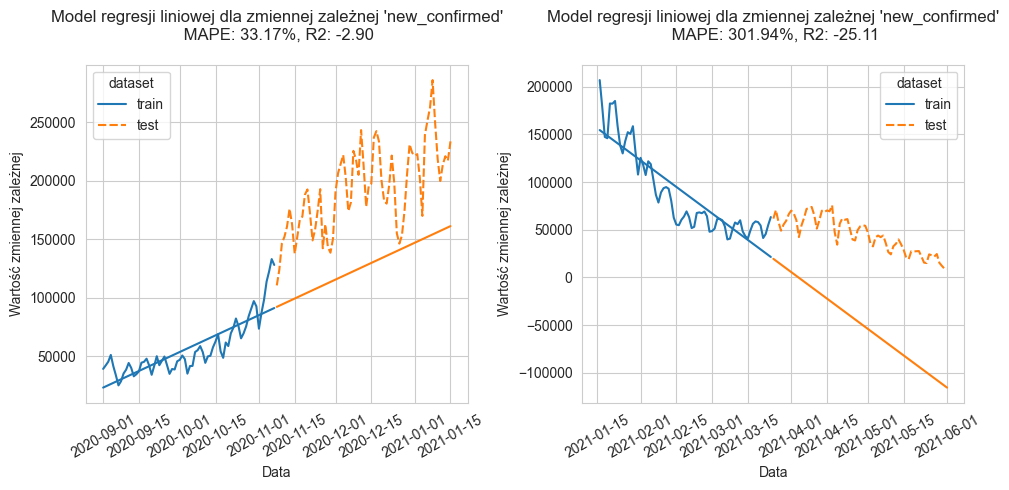

In [61]:
split_idx = len(y_new_confirmed_1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_linear_regression(
    y_new_confirmed_1_train, y_new_confirmed_1_test,
    y_new_confirmed_1_fit, y_new_confirmed_1_pred,
    df_us_filtered_by_date['date'][:split_idx], 'new_confirmed',
    ax=axes[0]
)

plot_linear_regression(
    y_new_confirmed_2_train, y_new_confirmed_2_test,
    y_new_confirmed_2_fit, y_new_confirmed_2_pred,
    df_us_filtered_by_date['date'][split_idx:], 'new_confirmed',
    ax=axes[1]
)

##### Liczba nowych śmierci.

In [62]:
X_new_deceased_1, X_new_deceased_2, y_new_deceased_1, y_new_deceased_2 = (
    train_test_split(X_new_deceased, y_new_deceased, test_size=0.5, shuffle=False)
)

X_new_deceased_1_train, X_new_deceased_1_test, y_new_deceased_1_train, y_new_deceased_1_test = (
    train_test_split(X_new_deceased_1, y_new_deceased_1, test_size=0.5, shuffle=False)
)

X_new_deceased_2_train, X_new_deceased_2_test, y_new_deceased_2_train, y_new_deceased_2_test = (
    train_test_split(X_new_deceased_2, y_new_deceased_2, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_new_deceased_1_train, y_new_deceased_1_train)
y_new_deceased_1_fit = reg.predict(X_new_deceased_1_train)
y_new_deceased_1_pred = reg.predict(X_new_deceased_1_test)

mape = mean_absolute_percentage_error(y_new_deceased_1_test, y_new_deceased_1_pred)
r2 = r2_score(y_new_deceased_1_test, y_new_deceased_1_pred)

print(f"Mean absolute percentage error (split 1): {mape * 100}%")
print(f"R2 score (split 1): {r2}")

reg = LinearRegression()
reg.fit(X_new_deceased_2_train, y_new_deceased_2_train)
y_new_deceased_2_fit = reg.predict(X_new_deceased_2_train)
y_new_deceased_2_pred = reg.predict(X_new_deceased_2_test)

mape = mean_absolute_percentage_error(y_new_deceased_2_test, y_new_deceased_2_pred)
r2 = r2_score(y_new_deceased_2_test, y_new_deceased_2_pred)

print(f"Mean absolute percentage error (split 2): {mape * 100}%")
print(f"R2 score (split 2): {r2}")

Mean absolute percentage error (split 1): 50.51114028746893%
R2 score (split 1): -2.366007546512211
Mean absolute percentage error (split 2): 295.7340080632401%
R2 score (split 2): -84.10169171589341


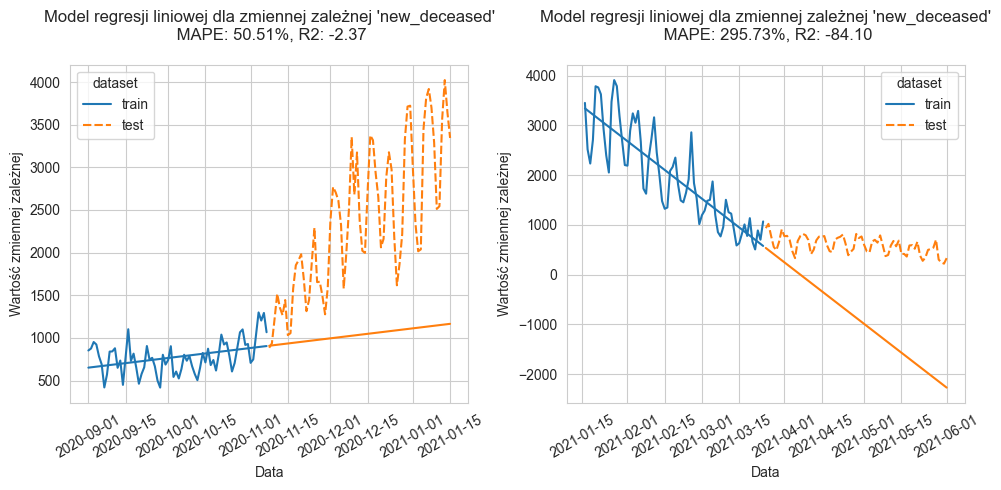

In [63]:
split_idx = len(y_new_deceased_1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_linear_regression(
    y_new_deceased_1_train, y_new_deceased_1_test,
    y_new_deceased_1_fit, y_new_deceased_1_pred,
    df_us_filtered_by_date['date'][:split_idx], 'new_deceased',
    ax=axes[0]
)

plot_linear_regression(
    y_new_deceased_2_train, y_new_deceased_2_test,
    y_new_deceased_2_fit, y_new_deceased_2_pred,
    df_us_filtered_by_date['date'][split_idx:], 'new_deceased',
    ax=axes[1]
)

##### Łączna liczba podanych dawek szczepionek

In [64]:
X_cumulative_vaccine_doses_administered_1, X_cumulative_vaccine_doses_administered_2, y_cumulative_vaccine_doses_administered_1, y_cumulative_vaccine_doses_administered_2 = (
    train_test_split(X_cumulative_vaccine_doses_administered, y_cumulative_vaccine_doses_administered, test_size=0.5, shuffle=False)
)

X_cumulative_vaccine_doses_administered_1_train, X_cumulative_vaccine_doses_administered_1_test, y_cumulative_vaccine_doses_administered_1_train, y_cumulative_vaccine_doses_administered_1_test = (
    train_test_split(X_cumulative_vaccine_doses_administered_1, y_cumulative_vaccine_doses_administered_1, test_size=0.5, shuffle=False)
)

X_cumulative_vaccine_doses_administered_2_train, X_cumulative_vaccine_doses_administered_2_test, y_cumulative_vaccine_doses_administered_2_train, y_cumulative_vaccine_doses_administered_2_test = (
    train_test_split(X_cumulative_vaccine_doses_administered_2, y_cumulative_vaccine_doses_administered_2, test_size=0.5, shuffle=False)
)

reg = LinearRegression()
reg.fit(X_cumulative_vaccine_doses_administered_1_train, y_cumulative_vaccine_doses_administered_1_train)
y_cumulative_vaccine_doses_administered_1_fit = reg.predict(X_cumulative_vaccine_doses_administered_1_train)
y_cumulative_vaccine_doses_administered_1_pred = reg.predict(X_cumulative_vaccine_doses_administered_1_test)

mape = mean_absolute_percentage_error(
    y_cumulative_vaccine_doses_administered_1_test,
    y_cumulative_vaccine_doses_administered_1_pred
)
r2 = r2_score(
    y_cumulative_vaccine_doses_administered_1_test,
    y_cumulative_vaccine_doses_administered_1_pred
)

print(f"Mean absolute percentage error (split 1): {mape * 100}%")
print(f"R2 score (split 1): {r2}")

reg = LinearRegression()
reg.fit(
    X_cumulative_vaccine_doses_administered_2_train,
    y_cumulative_vaccine_doses_administered_2_train
)
y_cumulative_vaccine_doses_administered_2_fit = reg.predict(
    X_cumulative_vaccine_doses_administered_2_train
)
y_cumulative_vaccine_doses_administered_2_pred = reg.predict(
    X_cumulative_vaccine_doses_administered_2_test
)

mape = mean_absolute_percentage_error(
    y_cumulative_vaccine_doses_administered_2_test,
    y_cumulative_vaccine_doses_administered_2_pred
)
r2 = r2_score(
    y_cumulative_vaccine_doses_administered_2_test,
    y_cumulative_vaccine_doses_administered_2_pred
)

print(f"Mean absolute percentage error (split 2): {mape * 100}%")
print(f"R2 score (split 2): {r2}")

Mean absolute percentage error (split 1): 49.275362318840585%
R2 score (split 1): -0.39220236552409027
Mean absolute percentage error (split 2): 15.50684050983392%
R2 score (split 2): 0.29653604993325566


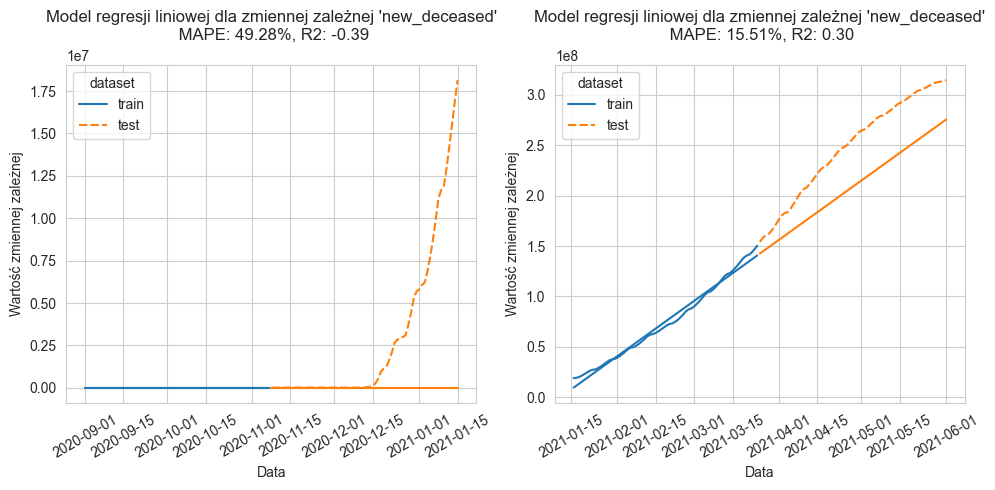

In [65]:
split_idx = len(y_cumulative_vaccine_doses_administered_1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_linear_regression(
    y_cumulative_vaccine_doses_administered_1_train, y_cumulative_vaccine_doses_administered_1_test,
    y_cumulative_vaccine_doses_administered_1_fit, y_cumulative_vaccine_doses_administered_1_pred,
    df_us_filtered_by_date['date'][:split_idx], 'new_deceased',
    ax=axes[0]
)

plot_linear_regression(
    y_cumulative_vaccine_doses_administered_2_train, y_cumulative_vaccine_doses_administered_2_test,
    y_cumulative_vaccine_doses_administered_2_fit, y_cumulative_vaccine_doses_administered_2_pred,
    df_us_filtered_by_date['date'][split_idx:], 'new_deceased',
    ax=axes[1]
)

## Część 4
**Misja dodatkowa – Regresja wielomianowa**

*W **regresji wielomianowej** zastosowanie wielomianów wyższych stopni pozwala na uwzględnienie nieliniowych związków między zmiennymi niezależnymi (np. czasem) a zmienną zależną (np. liczbą nowych zachorowań). Aby dobrać odpowiedni stopień wielomianu, można przeprowadzić walidację krzyżową lub podzielić dane na zbiory treningowe i testowe, a następnie obliczyć metryki błędów dla różnych stopni wielomianów.*

***Stopień zgodności modelu z danymi** można określić na podstawie miar dopasowania, np. odchylenia standardowego reszt, wariancji reszt, współczynnika zmienności losowej czy współczynnika determinacji.*

Użyj modelu regresji wielomianowej dla wszystkich 5 przypadków rozważanych w części 3 poziomu 3. Znajdź stopień wielomianu, który "najlepiej" pasuje do wybranych danych. Oceń, który model regresji (liniowy czy wielomianowy) okazał się "lepszy" dla każdego przypadku. W tym celu możesz użyć dowolnej miary dopasowania modelu. Uzasadnij swoje zdanie.

In [66]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline

In [67]:
def plot_polynomial_regression(y_train, y_test, y_pred_train, y_pred_test, dates_series, var_name, polynomial_degree, ax=None):
    mape = mean_absolute_percentage_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    train_test_split_idx = len(y_train)
    dates_train = dates_series[:train_test_split_idx]
    dates_test = dates_series[train_test_split_idx:]

    df_train = pd.DataFrame({
        'date': dates_train,
        'y_true': y_train,
        'y_pred': y_pred_train,
        'dataset': 'train'
    })

    df_test = pd.DataFrame({
        'date': dates_test,
        'y_true': y_test,
        'y_pred': y_pred_test,
        'dataset': 'test'
    })

    df_all = pd.concat([df_train, df_test], ignore_index=True)

    if ax is None:
        _, ax = plt.subplots()

    sns.lineplot(data=df_all, x='date', y='y_true', hue='dataset', style='dataset', ax=ax)
    sns.lineplot(data=df_all, x='date', y='y_pred', hue='dataset', legend=False, ax=ax)

    ax.set_xlabel('Data')
    ax.set_ylabel('Wartość zmiennej zależnej')
    for tick in ax.get_xticklabels():
        tick.set_rotation(30)

    ax.set_title(f"Model regresji wielomianowej dla zmiennej zależnej '{var_name}'"
              f'\n Stopień wielomianu: {polynomial_degree}, MAPE: {mape * 100:.2f}%, R2: {r2:.2f}',
              fontsize=11, y=1.05)

    plt.tight_layout()


#### **4.1.** liczba nowych zachorowań,

In [68]:
X_new_confirmed = df_us_filtered_by_date[['date_delta']]
y_new_confirmed = df_us_filtered_by_date['new_confirmed']

X_new_confirmed_1, X_new_confirmed_2, y_new_confirmed_1, y_new_confirmed_2 = (
    train_test_split(X_new_confirmed, y_new_confirmed, test_size=0.5, shuffle=False)
)

X_new_confirmed_1_train, X_new_confirmed_1_test, y_new_confirmed_1_train, y_new_confirmed_1_test = (
    train_test_split(X_new_confirmed_1, y_new_confirmed_1, test_size=0.5, shuffle=False)
)

X_new_confirmed_2_train, X_new_confirmed_2_test, y_new_confirmed_2_train, y_new_confirmed_2_test = (
    train_test_split(X_new_confirmed_2, y_new_confirmed_2, test_size=0.5, shuffle=False)
)

poly_reg = Pipeline(
    steps=[
        ('poly', PolynomialFeatures(include_bias=False)),
        ('reg', LinearRegression())
    ]
)

params = {
    'poly__degree': [2, 3, 4, 5, 6]
}

tscv = TimeSeriesSplit()
poly_reg = GridSearchCV(poly_reg, params, scoring='neg_mean_absolute_percentage_error', cv=tscv)

poly_reg.fit(X_new_confirmed_1_train, y_new_confirmed_1_train)
y_new_confirmed_1_fit = poly_reg.predict(X_new_confirmed_1_train)
y_new_confirmed_1_pred = poly_reg.predict(X_new_confirmed_1_test)

poly_degree_new_confirmed_1 = poly_reg.best_params_['poly__degree']
mape = mean_absolute_percentage_error(y_new_confirmed_1_test, y_new_confirmed_1_pred)
r2 = r2_score(y_new_confirmed_1_test, y_new_confirmed_1_pred)

print(f"Polynomial degree: {poly_degree_new_confirmed_1}")
print(f"Mean absolute percentage error (split 1): {mape * 100}%")
print(f"R2 score (split 1): {r2}")

poly_reg.fit(X_new_confirmed_2_train, y_new_confirmed_2_train)
y_new_confirmed_2_fit = poly_reg.predict(X_new_confirmed_2_train)
y_new_confirmed_2_pred = poly_reg.predict(X_new_confirmed_2_test)

poly_degree_new_confirmed_2 = poly_reg.best_params_['poly__degree']
mape = mean_absolute_percentage_error(y_new_confirmed_2_test, y_new_confirmed_2_pred)
r2 = r2_score(y_new_confirmed_2_test, y_new_confirmed_2_pred)

print(f"Polynomial degree: {poly_degree_new_confirmed_2}")
print(f"Mean absolute percentage error (split 2): {mape * 100}%")
print(f"R2 score (split 2): {r2}")

Polynomial degree: 2
Mean absolute percentage error (split 1): 43.78517698693199%
R2 score (split 1): -9.301463696802191
Polynomial degree: 2
Mean absolute percentage error (split 2): 609.527153555832%
R2 score (split 2): -92.68708307006005


#### **4.2.** liczba nowych śmierci,

In [69]:
X_new_deceased = df_us_filtered_by_date[['date_delta']]
y_new_deceased = df_us_filtered_by_date['new_deceased']

X_new_deceased_1, X_new_deceased_2, y_new_deceased_1, y_new_deceased_2 = (
    train_test_split(X_new_deceased, y_new_deceased, test_size=0.5, shuffle=False)
)

X_new_deceased_1_train, X_new_deceased_1_test, y_new_deceased_1_train, y_new_deceased_1_test = (
    train_test_split(X_new_deceased_1, y_new_deceased_1, test_size=0.5, shuffle=False)
)

X_new_deceased_2_train, X_new_deceased_2_test, y_new_deceased_2_train, y_new_deceased_2_test = (
    train_test_split(X_new_deceased_2, y_new_deceased_2, test_size=0.5, shuffle=False)
)

poly_reg = Pipeline(
    steps=[
        ('poly', PolynomialFeatures(include_bias=False)),
        ('reg', LinearRegression())
    ]
)

params = {
    'poly__degree': [2, 3, 4, 5, 6]
}

tscv = TimeSeriesSplit()
poly_reg = GridSearchCV(poly_reg, params, cv=tscv)

poly_reg.fit(X_new_deceased_1_train, y_new_deceased_1_train)
y_new_deceased_1_fit = poly_reg.predict(X_new_deceased_1_train)
y_new_deceased_1_pred = poly_reg.predict(X_new_deceased_1_test)

poly_degree_new_deceased_1 = poly_reg.best_params_['poly__degree']
mape = mean_absolute_percentage_error(y_new_deceased_1_test, y_new_deceased_1_pred)
r2 = r2_score(y_new_deceased_1_test, y_new_deceased_1_pred)

print(f"Polynomial degree: {poly_degree_new_deceased_1}")
print(f"Mean absolute percentage error (split 2): {mape * 100}%")
print(f"R2 score (split 2): {r2}")

poly_reg.fit(X_new_deceased_2_train, y_new_deceased_2_train)
y_new_deceased_2_fit = poly_reg.predict(X_new_deceased_2_train)
y_new_deceased_2_pred = poly_reg.predict(X_new_deceased_2_test)

poly_degree_new_deceased_2 = poly_reg.best_params_['poly__degree']
mape = mean_absolute_percentage_error(y_new_deceased_2_test, y_new_deceased_2_pred)
r2 = r2_score(y_new_deceased_2_test, y_new_deceased_2_pred)

print(f"Polynomial degree: {poly_degree_new_deceased_2}")
print(f"Mean absolute percentage error (split 2): {mape * 100}%")
print(f"R2 score (split 2): {r2}")

Polynomial degree: 2
Mean absolute percentage error (split 2): 21.06451070782015%
R2 score (split 2): 0.4914405234479188
Polynomial degree: 2
Mean absolute percentage error (split 2): 290.4040079844775%
R2 score (split 2): -81.13593544595243


#### **4.3.** liczba nowych szczepień,

In [70]:
X_new_persons_vaccinated = df_us_filtered_by_date[['date_delta']]
y_new_persons_vaccinated = df_us_filtered_by_date['new_persons_vaccinated'].fillna(0)

X_new_persons_vaccinated_train, X_new_persons_vaccinated_test, y_new_persons_vaccinated_train, y_new_persons_vaccinated_test = (
    train_test_split(X_new_persons_vaccinated, y_new_persons_vaccinated, test_size=0.5, shuffle=False)
)

poly_reg = Pipeline(
    steps=[
        ('poly', PolynomialFeatures(include_bias=False)),
        ('reg', LinearRegression())
    ]
)

params = {
    'poly__degree': [2, 3, 4, 5, 6]
}

tscv = TimeSeriesSplit()
poly_reg = GridSearchCV(poly_reg, params, cv=tscv)

poly_reg.fit(X_new_persons_vaccinated_train, y_new_persons_vaccinated_train)
y_new_persons_vaccinated_fit = poly_reg.predict(X_new_persons_vaccinated_train)
y_new_persons_vaccinated_pred = poly_reg.predict(X_new_persons_vaccinated_test)

poly_degree_new_persons_vaccinated = poly_reg.best_params_['poly__degree']
mape = mean_absolute_percentage_error(y_new_persons_vaccinated_test, y_new_persons_vaccinated_pred)
r2 = r2_score(y_new_persons_vaccinated_test, y_new_persons_vaccinated_pred)

print(f"Polynomial degree: {poly_degree_new_persons_vaccinated}")
print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Polynomial degree: 3
Mean absolute percentage error: 1034.120183951367%
R2 score: -198.74639992168306


#### **4.4.** trendy wyszukiwań frazy 'depression',

In [71]:
X_search_trends_depression = df_us_filtered_by_date[['date_delta']]
y_search_trends_depression = df_us_filtered_by_date['search_trends_depression']

X_search_trends_depression_train, X_search_trends_depression_test, y_search_trends_depression_train, y_search_trends_depression_test = (
    train_test_split(X_search_trends_depression, y_search_trends_depression, test_size=0.5, shuffle=False)
)

poly_reg = Pipeline(
    steps=[
        ('poly', PolynomialFeatures(include_bias=False)),
        ('reg', LinearRegression())
    ]
)

params = {
    'poly__degree': [2, 3, 4, 5, 6]
}

tscv = TimeSeriesSplit()
poly_reg = GridSearchCV(poly_reg, params, cv=tscv)

poly_reg.fit(X_search_trends_depression_train, y_search_trends_depression_train)
y_search_trends_depression_fit = poly_reg.predict(X_search_trends_depression_train)
y_search_trends_depression_pred = poly_reg.predict(X_search_trends_depression_test)

poly_degree_search_trends_depression = poly_reg.best_params_['poly__degree']
mape = mean_absolute_percentage_error(y_search_trends_depression_test, y_search_trends_depression_pred)
r2 = r2_score(y_search_trends_depression_test, y_search_trends_depression_pred)

print(f"Polynomial degree: {poly_degree_search_trends_depression}")
print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Polynomial degree: 2
Mean absolute percentage error: 72.20912512053125%
R2 score: -56.22453352829884


#### **4.5.** łączna liczba podanych dawek szczepionek.

In [72]:
X_cumulative_vaccine_doses_administered = df_us_filtered_by_date[['date_delta']]
y_cumulative_vaccine_doses_administered = df_us_filtered_by_date['cumulative_vaccine_doses_administered'].fillna(0)

X_cumulative_vaccine_doses_administered_train, X_cumulative_vaccine_doses_administered_test, y_cumulative_vaccine_doses_administered_train, y_cumulative_vaccine_doses_administered_test = (
    train_test_split(X_cumulative_vaccine_doses_administered, y_cumulative_vaccine_doses_administered, test_size=0.5, shuffle=False)
)

poly_reg = Pipeline(
    steps=[
        ('poly', PolynomialFeatures(include_bias=False)),
        ('reg', LinearRegression())
    ]
)

params = {
    'poly__degree': [2, 3, 4, 5, 6]
}

tscv = TimeSeriesSplit()
poly_reg = GridSearchCV(poly_reg, params, cv=tscv)

poly_reg.fit(X_cumulative_vaccine_doses_administered_train, y_cumulative_vaccine_doses_administered_train)
y_cumulative_vaccine_doses_administered_fit = poly_reg.predict(X_cumulative_vaccine_doses_administered_train)
y_cumulative_vaccine_doses_administered_pred = poly_reg.predict(X_cumulative_vaccine_doses_administered_test)

poly_degree_cumulative_vaccine_doses_administered = poly_reg.best_params_['poly__degree']
mape = mean_absolute_percentage_error(y_cumulative_vaccine_doses_administered_test, y_cumulative_vaccine_doses_administered_pred)
r2 = r2_score(y_cumulative_vaccine_doses_administered_test, y_cumulative_vaccine_doses_administered_pred)

print(f"Polynomial degree: {poly_degree_cumulative_vaccine_doses_administered}")
print(f"Mean absolute percentage error: {mape * 100}%")
print(f"R2 score: {r2}")

Polynomial degree: 5
Mean absolute percentage error: 280.62598420074767%
R2 score: -113.3599068880131


#### Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi itp.). Przeanalizuj otrzymane wizualizacje.

##### **Ad. 4.1.**

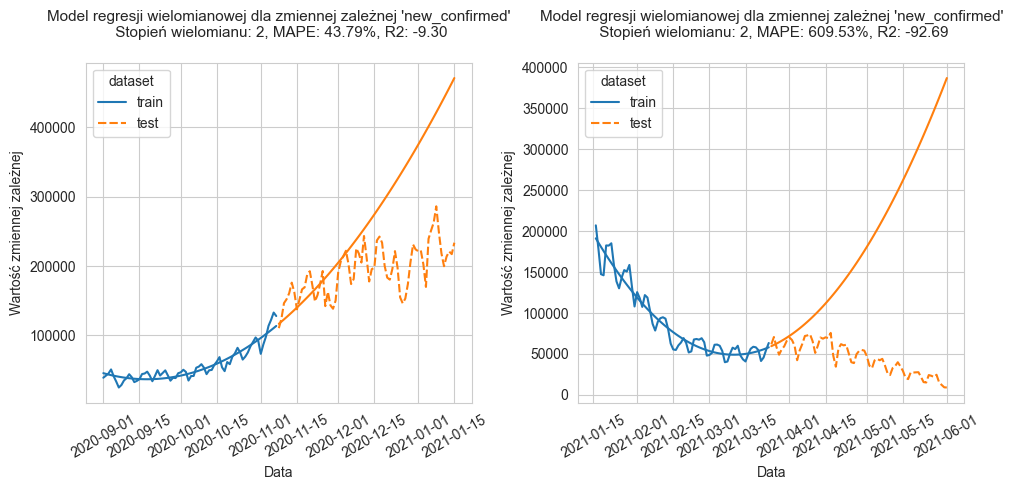

In [73]:
split_idx = len(y_new_confirmed_1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_polynomial_regression(
    y_new_confirmed_1_train, y_new_confirmed_1_test,
    y_new_confirmed_1_fit, y_new_confirmed_1_pred,
    df_us_filtered_by_date['date'][:split_idx], 'new_confirmed',
    poly_degree_new_confirmed_1, ax=axes[0]
)

plot_polynomial_regression(
    y_new_confirmed_2_train, y_new_confirmed_2_test,
    y_new_confirmed_2_fit, y_new_confirmed_2_pred,
    df_us_filtered_by_date['date'][split_idx:], 'new_confirmed',
    poly_degree_new_confirmed_2, ax=axes[1]
)

##### **Ad. 4.2.**

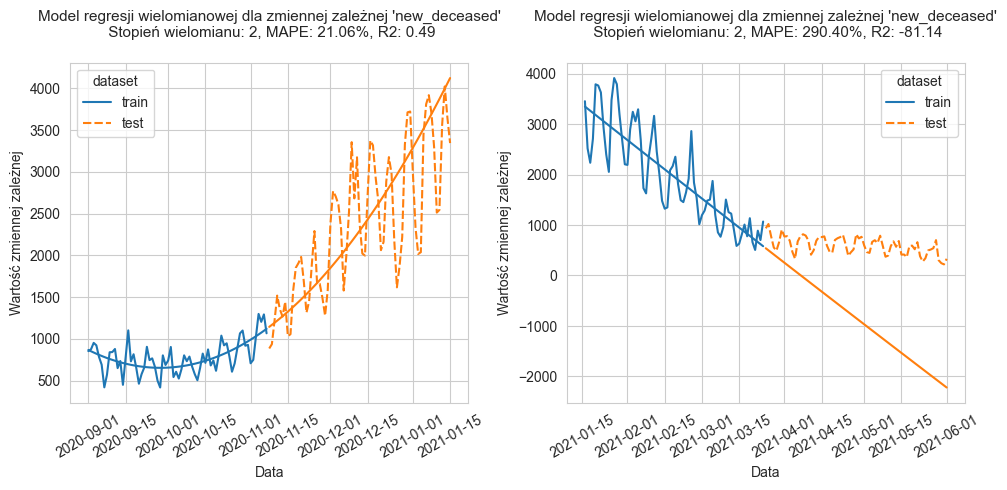

In [74]:
split_idx = len(y_new_deceased_1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

plot_polynomial_regression(
    y_new_deceased_1_train, y_new_deceased_1_test,
    y_new_deceased_1_fit, y_new_deceased_1_pred,
    df_us_filtered_by_date['date'][:split_idx], 'new_deceased',
    poly_degree_new_deceased_1, ax=axes[0]
)

plot_polynomial_regression(
    y_new_deceased_2_train, y_new_deceased_2_test,
    y_new_deceased_2_fit, y_new_deceased_2_pred,
    df_us_filtered_by_date['date'][split_idx:], 'new_deceased',
    poly_degree_new_deceased_2, ax=axes[1]
)

##### **Ad. 4.3.**

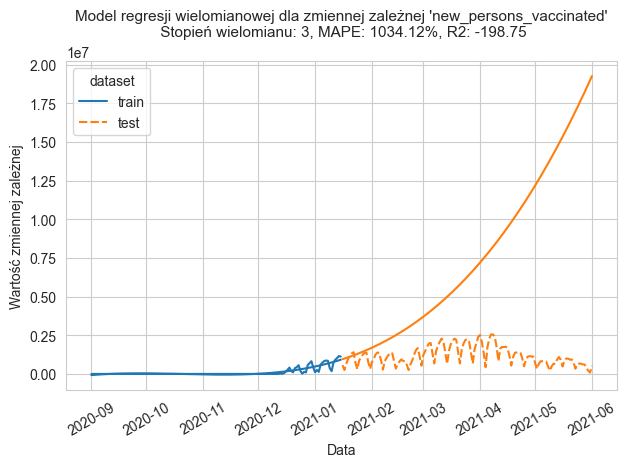

In [75]:
plot_polynomial_regression(
    y_new_persons_vaccinated_train, y_new_persons_vaccinated_test,
    y_new_persons_vaccinated_fit, y_new_persons_vaccinated_pred,
    df_us_filtered_by_date['date'], 'new_persons_vaccinated',
    poly_degree_new_persons_vaccinated
)

##### **Ad. 4.4.**

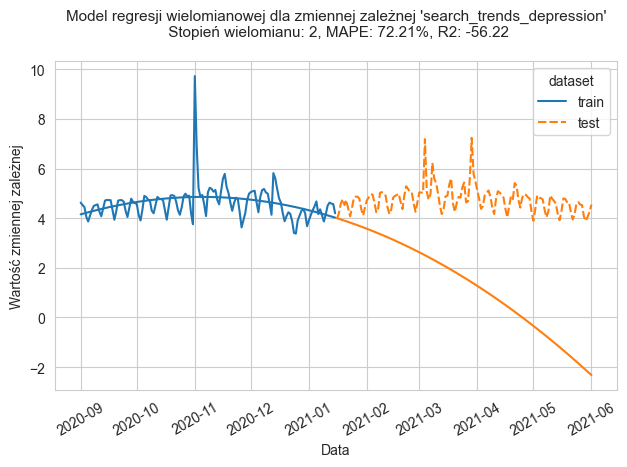

In [76]:
plot_polynomial_regression(
    y_search_trends_depression_train, y_search_trends_depression_test,
    y_search_trends_depression_fit, y_search_trends_depression_pred,
    df_us_filtered_by_date['date'], 'search_trends_depression',
    poly_degree_search_trends_depression
)

##### **Ad. 4.5.**

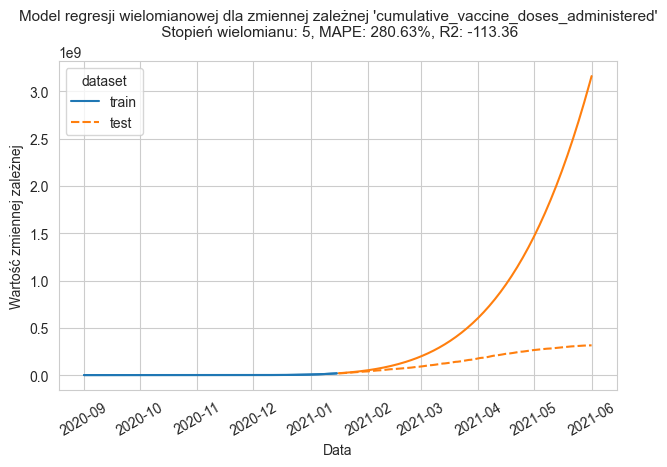

In [77]:
plot_polynomial_regression(
    y_cumulative_vaccine_doses_administered_train, y_cumulative_vaccine_doses_administered_test,
    y_cumulative_vaccine_doses_administered_fit, y_cumulative_vaccine_doses_administered_pred,
    df_us_filtered_by_date['date'], 'cumulative_vaccine_doses_administered',
    poly_degree_cumulative_vaccine_doses_administered
)

## Część 5

*Porównanie przebiegu pandemii w różnych miejscach na świecie pozwala lepiej zrozumieć, jak warunki geograficzne i społeczne mogą wpływać na liczbę zachorowań, zgonów czy szczepień.*

Wybierz minimum 2 kraje, które ze sobą porównasz. Jako kryterium wyboru wybierz jedną z cech, np. wielkość populacji, położenie geograficzne, czy wartość PKB. Preferowany jest taki wybór, aby móc porównać kraje położone w różnych częściach świata (np. jeden z półkuli północnej, drugi z południowej).

Przefiltruj zbiór danych, aby uzyskać osobne podzbiory dla wybranych krajów. Zachowaj ten sam okres (np. druga połowa 2020 roku i pierwsza połowa 2021 roku, czyli 52 tygodnie = X) tak, aby modele regresji były porównywalne. Upewnij się, że w każdym podzbiorze masz dane o tych samych zmiennych zależnych.

In [78]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    df_countries['new_confirmed_per_100_000'] = (
        df_countries['new_confirmed'] / df_countries['population'] * 100_000
    )

    df_countries['new_persons_vaccinated_per_1000'] = (
        df_countries['new_persons_vaccinated'] / df_countries['population'] * 1000
    )

    df_countries['percent_population_vaccinated'] = (
        (df_countries['cumulative_persons_vaccinated'] / df_countries['population']) * 100
    )

    df_countries['new_deceased_per_100_000'] = (
        df_countries['new_deceased'] / df_countries['population'] * 100_000
    )

In [79]:
df_countries_filtered_by_date = df_countries.copy()

df_countries_filtered_by_date = df_countries_filtered_by_date[
    (df_countries_filtered_by_date['date'] >= '2020-09-01') &
    (df_countries_filtered_by_date['date'] <= '2021-06-01')
]

df_countries_filtered_by_date['date_delta'] = (
    (df_countries_filtered_by_date['date'] - df_countries_filtered_by_date['date'].min()) /
    np.timedelta64(1, 'D')
)

In [80]:
df_us_filtered_by_date = df_countries_filtered_by_date.query("iso_3166_1_alpha_2 == 'US'")
df_singapore_filtered_by_date = df_countries_filtered_by_date.query("iso_3166_1_alpha_2 == 'SG'")

Zbuduj model regresji liniowej dla każdego kraju, w którym zmienną niezależną będzie czas, a zmiennymi zależnymi wartości z części 3 poziomu 3:

In [81]:
def evaluate_linear_regression(X, y, test_size=0.5, shuffle=False):
    y = y.fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=shuffle)

    reg = LinearRegression()
    reg.fit(X_train, y_train)

    y_train_fit = reg.predict(X_train)
    y_test_pred = reg.predict(X_test)

    mape = mean_absolute_percentage_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    metrics = {'mape': mape, 'r2': r2}

    print(f"Mean Absolute Percentage Error: {mape * 100:.2f}%")
    print(f"R² Score: {r2:.4f}")

    return {
        'model': reg,
        'X_train': X_train,
        'y_train': y_train,
        'y_train_fit': y_train_fit,
        'X_test': X_test,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'metrics': metrics
    }

#### **5.1.** liczba nowych zachorowań,

In [82]:
results_new_confirmed_us = evaluate_linear_regression(
    df_us_filtered_by_date[['date_delta']],
    df_us_filtered_by_date['new_confirmed_per_100_000']
)

Mean Absolute Percentage Error: 783.39%
R² Score: -61.7524


In [83]:
results_new_confirmed_singapore = evaluate_linear_regression(
    df_singapore_filtered_by_date[['date_delta']],
    df_singapore_filtered_by_date['new_confirmed_per_100_000']
)

Mean Absolute Percentage Error: 59.98%
R² Score: -1.6319


#### **5.2.** liczba nowych śmierci,

In [84]:
results_new_deceased_us = evaluate_linear_regression(
    df_us_filtered_by_date[['date_delta']],
    df_us_filtered_by_date['new_deceased_per_100_000']
)

Mean Absolute Percentage Error: 551.07%
R² Score: -14.1659


In [85]:
results_new_deceased_singapore = evaluate_linear_regression(
    df_singapore_filtered_by_date[['date_delta']],
    df_singapore_filtered_by_date['new_deceased_per_100_000']
)

Mean Absolute Percentage Error: 66431410024400.17%
R² Score: -0.0178


#### **5.3.** liczba nowych szczepień,

In [86]:
results_new_persons_vaccinated_us = evaluate_linear_regression(
    df_us_filtered_by_date[['date_delta']],
    df_us_filtered_by_date['new_persons_vaccinated_per_1000']
)

Mean Absolute Percentage Error: 60.27%
R² Score: -0.7891


In [87]:
results_new_persons_vaccinated_singapore = evaluate_linear_regression(
    df_singapore_filtered_by_date[['date_delta']],
    df_singapore_filtered_by_date['new_persons_vaccinated_per_1000']
)

Mean Absolute Percentage Error: 184.39%
R² Score: -2.9574


#### **5.4.** 2 inne różne informacje, które uznasz za istotne.

##### **5.4.1.** Trendy wyszukiwań frazy 'depression',

In [88]:
results_search_trends_depression_us = evaluate_linear_regression(
    df_us_filtered_by_date[['date_delta']],
    df_us_filtered_by_date['search_trends_depression']
)

Mean Absolute Percentage Error: 8.37%
R² Score: -0.2934


In [89]:
results_search_trends_depression_singapore = evaluate_linear_regression(
    df_singapore_filtered_by_date[['date_delta']],
    df_singapore_filtered_by_date['search_trends_depression']
)

Mean Absolute Percentage Error: 15.02%
R² Score: -2.2938


##### **5.4.2.** procent zaszczepionej populacji.

In [90]:
results_cumulative_vaccine_doses_administered_us = evaluate_linear_regression(
    df_us_filtered_by_date[['date_delta']],
    df_us_filtered_by_date['percent_population_vaccinated']
)

Mean Absolute Percentage Error: 88.74%
R² Score: -2.8431


In [91]:
results_cumulative_vaccine_doses_administered_singapore = evaluate_linear_regression(
    df_singapore_filtered_by_date[['date_delta']],
    df_singapore_filtered_by_date['percent_population_vaccinated']
)

Mean Absolute Percentage Error: 99.17%
R² Score: -1.6982


#### Przygotuj wykresy w celu porównania otrzymanych wyników. Pamiętaj o ich czytelności (typ wykresu, tytuł wykresu, podpisy osi, odpowiednie zakresy osi itp.). Przeanalizuj otrzymane wizualizacje. Zastanów się, jakie czynniki (np. strategia testowania, restrykcje, wielkość populacji, strefa klimatyczna itp.) mogły wpłynąć na różnice w uzyskanych wynikach. Uzasadnij swoje wnioski, odnosząc się do specyfiki krajów (np. położenie geograficzne, gęstość zaludnienia, infrastruktura medyczna itp.).

##### **Ad. 5.1.**

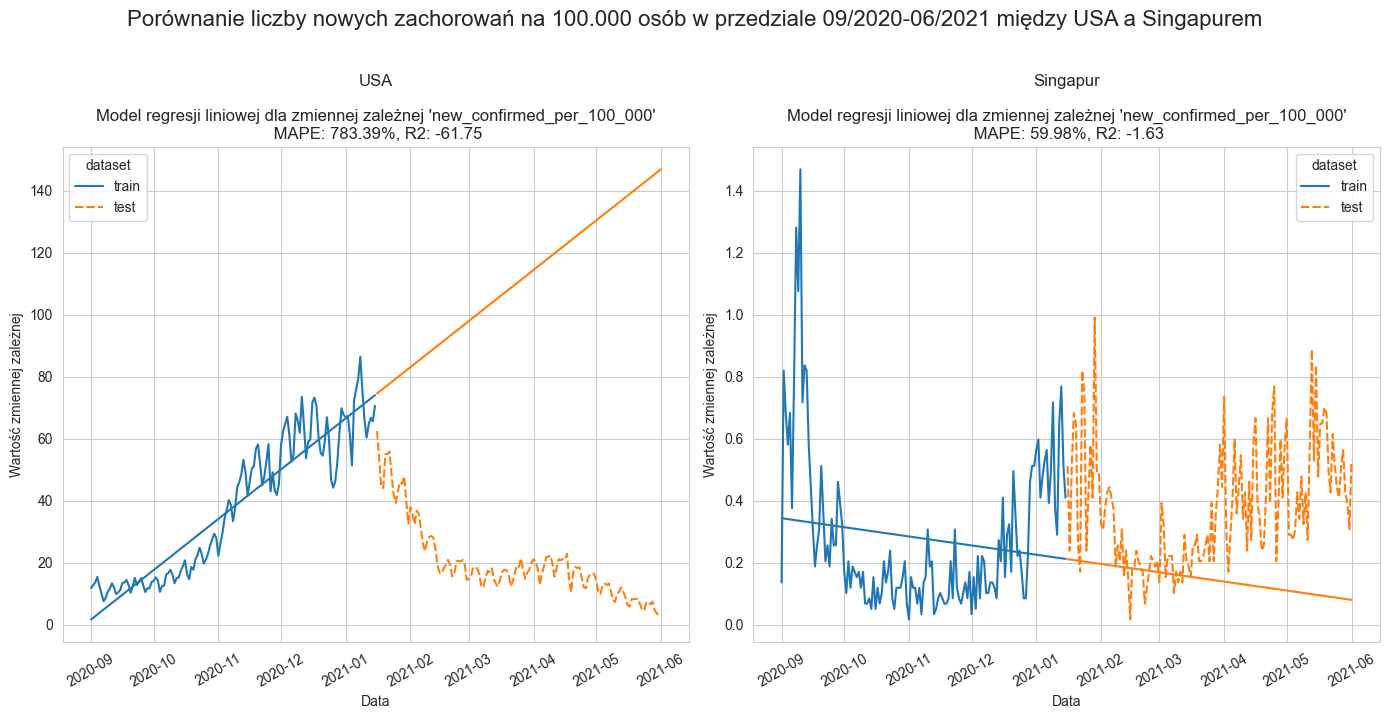

In [92]:
split_idx = len(df_us_filtered_by_date)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_linear_regression(
    results_new_confirmed_us['y_train'], results_new_confirmed_us['y_test'],
    results_new_confirmed_us['y_train_fit'], results_new_confirmed_us['y_test_pred'],
    df_us_filtered_by_date['date'][:split_idx], 'new_confirmed_per_100_000',
    ax=axes[0]
)
axes[0].set_title('USA\n\n' + axes[0].get_title())

plot_linear_regression(
    results_new_confirmed_singapore['y_train'], results_new_confirmed_singapore['y_test'],
    results_new_confirmed_singapore['y_train_fit'], results_new_confirmed_singapore['y_test_pred'],
    df_singapore_filtered_by_date['date'][:split_idx], 'new_confirmed_per_100_000',
    ax=axes[1]
)
axes[1].set_title('Singapur\n\n' + axes[1].get_title())

plt.suptitle(
    'Porównanie liczby nowych zachorowań na 100.000 osób w przedziale 09/2020-06/2021 między USA a Singapurem',
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()

##### **Ad. 5.2.**

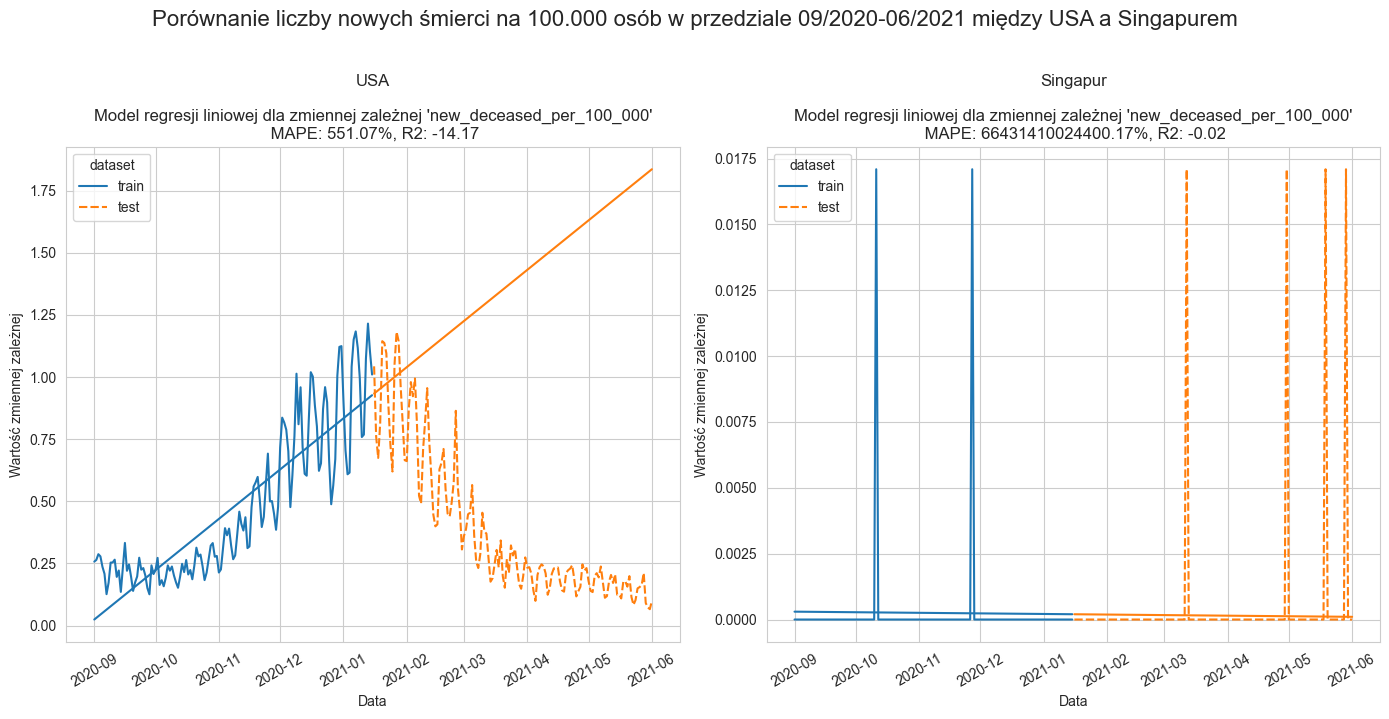

In [93]:
split_idx = len(df_us_filtered_by_date)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_linear_regression(
    results_new_deceased_us['y_train'], results_new_deceased_us['y_test'],
    results_new_deceased_us['y_train_fit'], results_new_deceased_us['y_test_pred'],
    df_us_filtered_by_date['date'][:split_idx], 'new_deceased_per_100_000',
    ax=axes[0]
)
axes[0].set_title('USA\n\n' + axes[0].get_title())

plot_linear_regression(
    results_new_deceased_singapore['y_train'], results_new_deceased_singapore['y_test'],
    results_new_deceased_singapore['y_train_fit'], results_new_deceased_singapore['y_test_pred'],
    df_singapore_filtered_by_date['date'][:split_idx], 'new_deceased_per_100_000',
    ax=axes[1]
)
axes[1].set_title('Singapur\n\n' + axes[1].get_title())

plt.suptitle(
    'Porównanie liczby nowych śmierci na 100.000 osób w przedziale 09/2020-06/2021 między USA a Singapurem',
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()

##### **Ad. 5.3.**

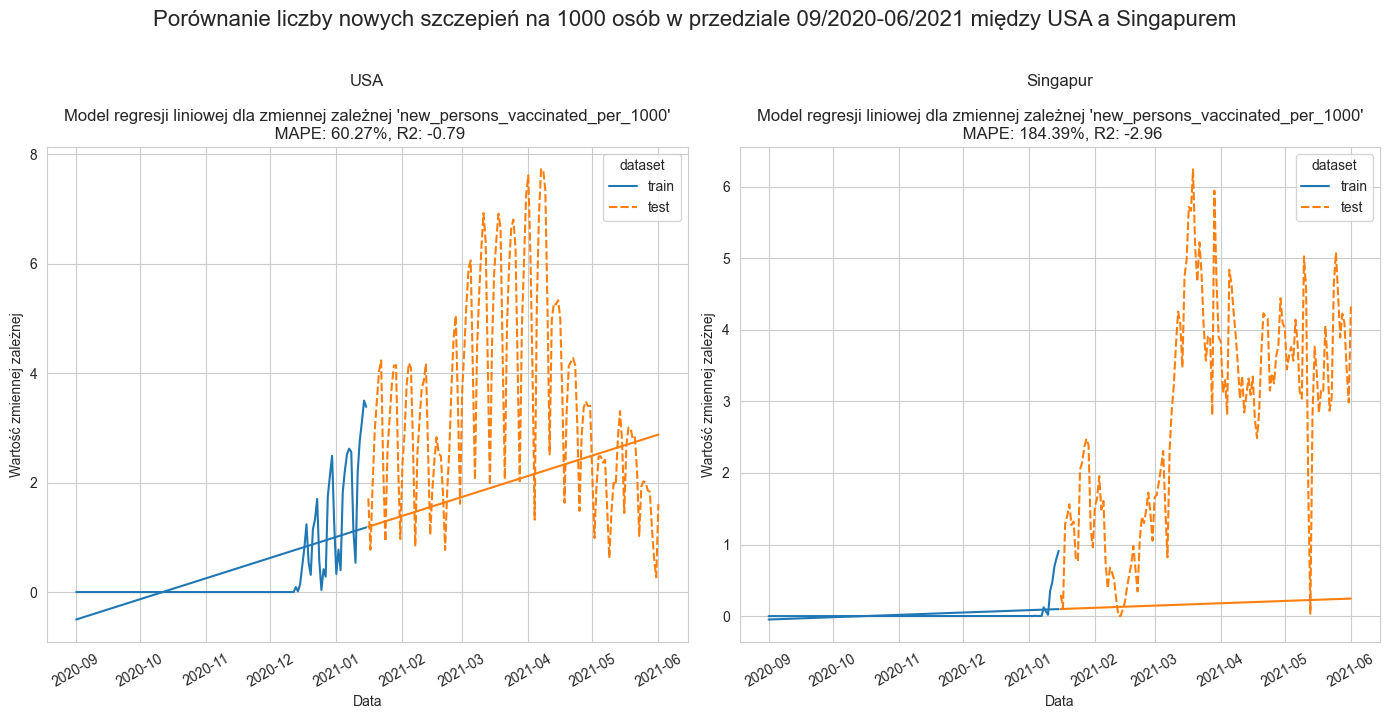

In [94]:
split_idx = len(df_us_filtered_by_date)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_linear_regression(
    results_new_persons_vaccinated_us['y_train'], results_new_persons_vaccinated_us['y_test'],
    results_new_persons_vaccinated_us['y_train_fit'], results_new_persons_vaccinated_us['y_test_pred'],
    df_us_filtered_by_date['date'][:split_idx], 'new_persons_vaccinated_per_1000',
    ax=axes[0]
)
axes[0].set_title('USA\n\n' + axes[0].get_title())

plot_linear_regression(
    results_new_persons_vaccinated_singapore['y_train'], results_new_persons_vaccinated_singapore['y_test'],
    results_new_persons_vaccinated_singapore['y_train_fit'], results_new_persons_vaccinated_singapore['y_test_pred'],
    df_singapore_filtered_by_date['date'][:split_idx], 'new_persons_vaccinated_per_1000',
    ax=axes[1]
)
axes[1].set_title('Singapur\n\n' + axes[1].get_title())

plt.suptitle(
    'Porównanie liczby nowych szczepień na 1000 osób w przedziale 09/2020-06/2021 między USA a Singapurem',
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()

##### **Ad. 5.4.1.**

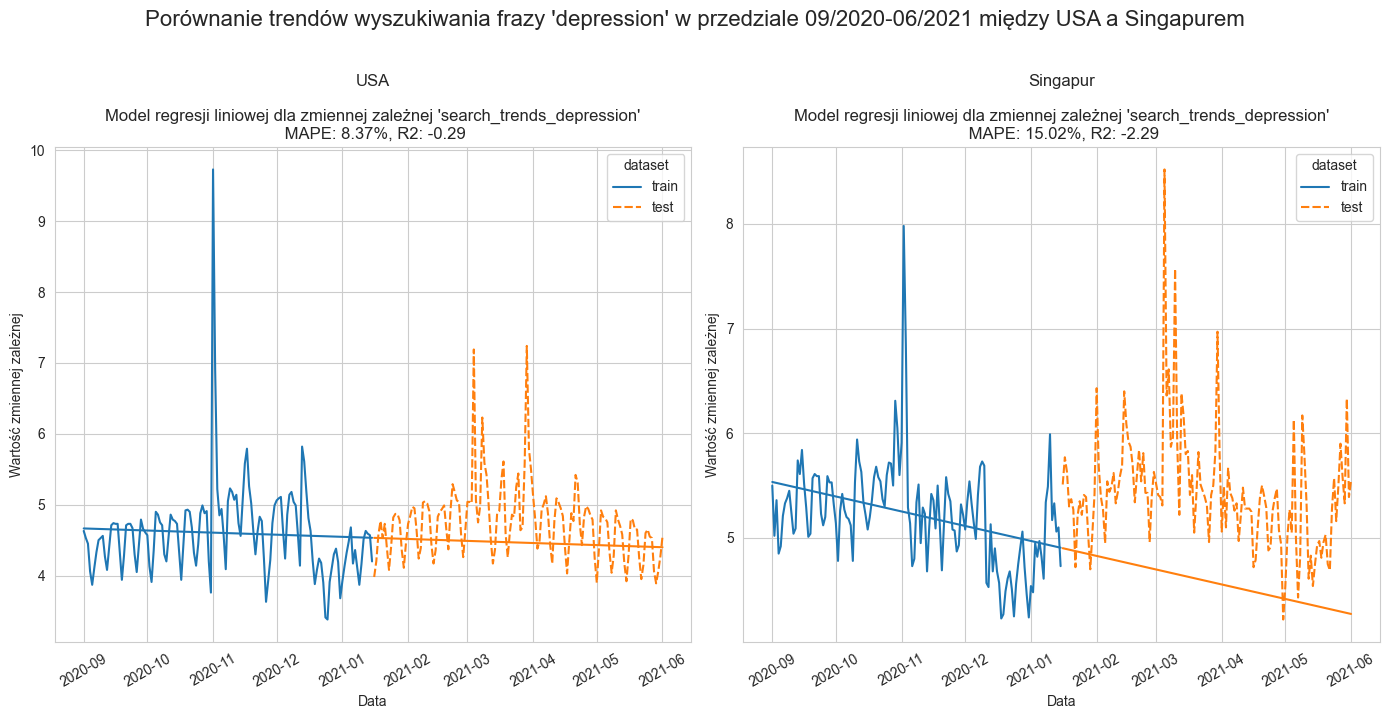

In [95]:
split_idx = len(df_us_filtered_by_date)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_linear_regression(
    results_search_trends_depression_us['y_train'], results_search_trends_depression_us['y_test'],
    results_search_trends_depression_us['y_train_fit'], results_search_trends_depression_us['y_test_pred'],
    df_us_filtered_by_date['date'][:split_idx], 'search_trends_depression',
    ax=axes[0]
)
axes[0].set_title('USA\n\n' + axes[0].get_title())

plot_linear_regression(
    results_search_trends_depression_singapore['y_train'], results_search_trends_depression_singapore['y_test'],
    results_search_trends_depression_singapore['y_train_fit'], results_search_trends_depression_singapore['y_test_pred'],
    df_singapore_filtered_by_date['date'][:split_idx], 'search_trends_depression',
    ax=axes[1]
)
axes[1].set_title('Singapur\n\n' + axes[1].get_title())

plt.suptitle(
    "Porównanie trendów wyszukiwania frazy 'depression' w przedziale 09/2020-06/2021 między USA a Singapurem",
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()

##### **Ad. 5.4.2.**

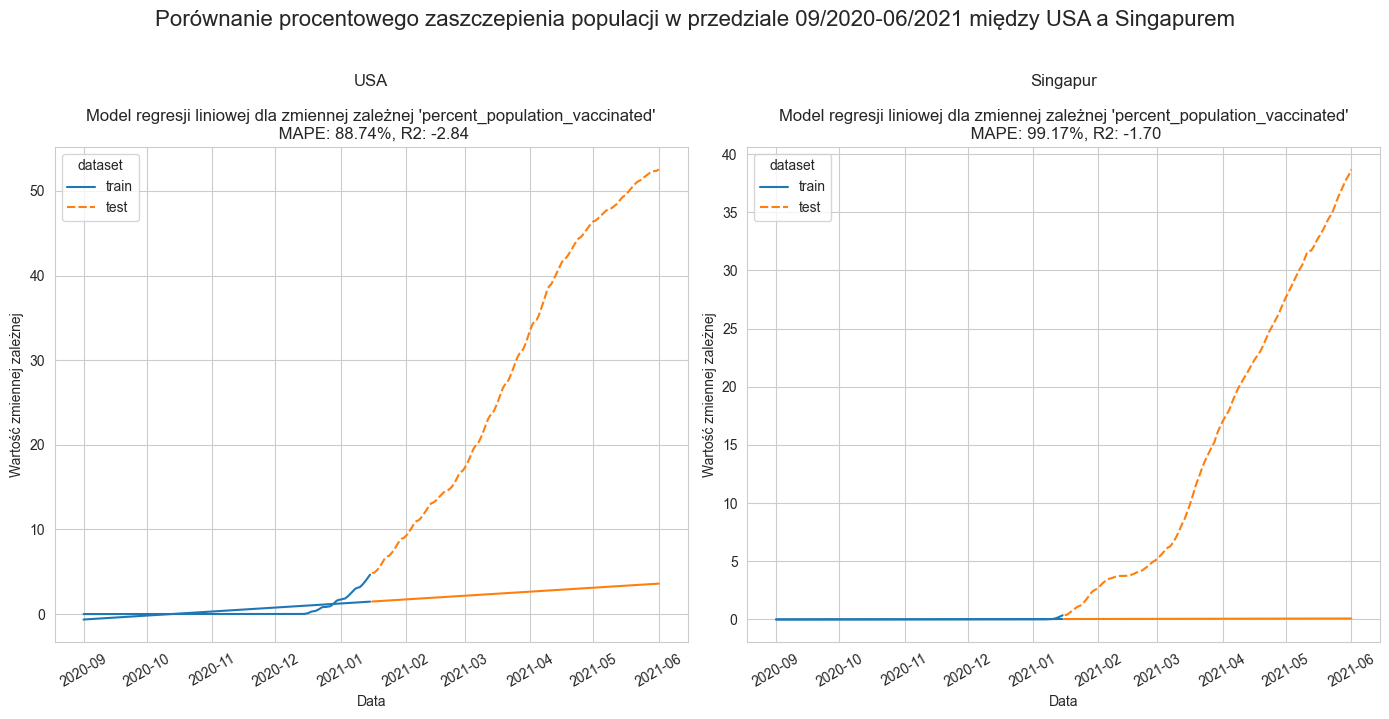

In [96]:
split_idx = len(df_us_filtered_by_date)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_linear_regression(
    results_cumulative_vaccine_doses_administered_us['y_train'], results_cumulative_vaccine_doses_administered_us['y_test'],
    results_cumulative_vaccine_doses_administered_us['y_train_fit'], results_cumulative_vaccine_doses_administered_us['y_test_pred'],
    df_us_filtered_by_date['date'][:split_idx], 'percent_population_vaccinated',
    ax=axes[0]
)
axes[0].set_title('USA\n\n' + axes[0].get_title())

plot_linear_regression(
    results_cumulative_vaccine_doses_administered_singapore['y_train'], results_cumulative_vaccine_doses_administered_singapore['y_test'],
    results_cumulative_vaccine_doses_administered_singapore['y_train_fit'], results_cumulative_vaccine_doses_administered_singapore['y_test_pred'],
    df_singapore_filtered_by_date['date'][:split_idx], 'percent_population_vaccinated',
    ax=axes[1]
)
axes[1].set_title('Singapur\n\n' + axes[1].get_title())

plt.suptitle(
    'Porównanie procentowego zaszczepienia populacji w przedziale 09/2020-06/2021 między USA a Singapurem',
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()